# 🏗️ ML System Design — From a Vague Prompt to a Defensible Design

> **What you'll practise:** the 45–60 minute ML system design round. You get an 11-step framework, eight building blocks that most designs reuse (two-stage retrieval, embeddings + approximate nearest neighbours, real-time features, caching, cold start, position bias, class imbalance, fairness and privacy), five end-to-end case studies with architecture diagrams and capacity estimates **computed from stated assumptions**, and small real demos on MovieLens: point-in-time feature joins, candidate recall@k, re-ranking and A/B test sizing.

| | |
|---|---|
| **Difficulty** | 🟡 Intermediate → 🔴 Advanced |
| **Time** | ~6 hours to read, run and answer out loud, + 3 × 45-minute timed drills |
| **Prerequisites** | [ML Fundamentals From Scratch](../03_Classical_Machine_Learning/01_ML_Fundamentals_From_Scratch.ipynb) · [Statistics & Probability](../01_Core_Scientific_Computing/05_Statistics_and_Probability.ipynb) (A/B tests, power) · [SQL with DuckDB](../01_Core_Scientific_Computing/03_SQL_with_DuckDB.ipynb) (MovieLens, leakage-free features) · [Embeddings and Semantic Search](../05_NLP/02_Embeddings_and_Semantic_Search.ipynb) · [Model Monitoring & Drift](../09_MLOps/05_Model_Monitoring_and_Drift.ipynb) |
| **Tested with** | Python 3.12 · pandas 3.0 · numpy 2.5 · scikit-learn 1.9 · scipy 1.18 · statsmodels 0.15 · faiss-cpu 1.15 · matplotlib 3 |
| **Interview relevance** | ⭐⭐⭐ Very high — most ML engineer, applied scientist and AI engineer loops from mid-level up include a design round, and the depth you show there is a key signal for senior levels |

## 🎯 How This Round Works

The interviewer gives you a short, deliberately vague prompt, such as *"Design the home feed for a video app"* or *"Detect fraudulent payments"*. You have **45–60 minutes** and a whiteboard, a shared doc or a drawing tool. There is usually **no code**. There is also no single right answer. The interviewer is watching **how you think**: do you turn an ambiguous business problem into a working ML system, and can you defend each choice?

Think of it like an architect meeting a client. A good architect doesn't start by choosing bricks. They ask who will live in the house, what the budget is and what the local rules are. Then they sketch a plan, explain the trade-offs and show how the house will be inspected and maintained.

### A typical 45-minute timeline

| Minutes | You do | You write on the board |
|---|---|---|
| 0–5 | Clarify the goal, users, scale and constraints | Bullet list of assumptions, with numbers |
| 5–10 | Define business, online and offline metrics, plus guardrails | A metrics table |
| 10–18 | Data sources, labels, features | Data → label → feature list |
| 18–25 | Baseline → model choice → training pipeline | Model ladder, training diagram |
| 25–33 | Serving architecture, latency budget, capacity estimate | Boxes and arrows, back-of-the-envelope numbers |
| 33–40 | Offline evaluation → A/B test plan | Metrics, sample size, guardrails |
| 40–45 | Monitoring, failure modes, next iterations, summary | Risks and fallbacks list |

In a **60-minute** round, the extra 15 minutes usually become a **deep dive** that the interviewer picks: candidate generation, feature freshness, the A/B test, or scaling. Leave room for it.

### What is scored

| Dimension | Strong signal | Weak signal |
|---|---|---|
| **Problem framing & structure** | Asks clarifying questions, states assumptions with numbers, follows a visible plan | Jumps straight to "I'd use a transformer" |
| **Metrics** | Links a business goal → online metric → offline metric, and names guardrails | Only "accuracy", or no metrics at all |
| **Data & features** | Knows where labels come from, handles leakage, delay and bias | Assumes a clean labelled dataset exists |
| **Modelling** | Starts from a baseline and explains why each step up in complexity pays off | Picks the fanciest model without a reason |
| **Serving & scale** | Latency budget, batch vs online, capacity numbers, caching | "Deploy it on Kubernetes" with nothing else |
| **Evaluation** | Offline metrics + a correctly sized A/B test + guardrails | "If the offline AUC is higher, ship it" |
| **Trade-offs** | Names 2–3 options, picks one, says what would change the decision | Presents one option as obviously correct |
| **Iteration & operations** | Monitoring, retraining, failure modes, feedback loops | The design stops at "deploy" |

### How to drive the conversation

1. **Say the plan out loud first:** *"I'll clarify requirements, set metrics, then go data → features → model → serving → evaluation → monitoring. Stop me anywhere you want more depth."*
2. **Put numbers on assumptions** (users, items, QPS, latency) and write them down. Estimates that are roughly right beat vague words.
3. **Start simple, then improve:** a heuristic or popularity baseline first, then the ML version, then the advanced version.
4. **Check in every ~10 minutes:** *"Should I go deeper on candidate generation, or move on to serving?"* The interviewer's hints are part of the test.
5. **Name trade-offs explicitly:** *"Batch precomputation is cheaper, but it can't react to what the user did in the last five minutes, so I'd add…"*
6. **Close with a 30-second summary:** the design, the top risks and what you'd build next.

> **Seniority changes the bar.** A mid-level candidate should produce a sound end-to-end design. A senior candidate is also expected to find the hard parts without being prompted (label quality, feedback loops, the offline–online gap, cost) and to go deep in one or two of them.

### About the numbers in this notebook

Every number is either **computed in a code cell from assumptions you can see and change**, or **cited to a source**. Assumptions such as "50M daily users" are *illustrative inputs*, not facts about any company. In an interview, you would ask for them or propose them out loud.

Architecture diagrams use **Mermaid**. GitHub and JupyterLab 4.1+ draw them as diagrams. If your viewer shows the text instead, paste it into the [Mermaid Live Editor](https://mermaid.live/).

### Table of contents

| Part | Sections |
|---|---|
| **The framework** | [1. Framework at a glance](#1.-The-Framework-at-a-Glance-🟢) · [2. Goals, constraints, metrics](#2.-Clarify-Goals,-Constraints,-and-Metrics-🟢) · [3. Data, labels, features](#3.-Data,-Labels,-and-Point-in-Time-Correct-Features-🟡) · [4. Baselines & training](#4.-Baselines,-Model-Choice,-and-the-Training-Pipeline-🟢) · [5. Serving](#5.-Serving:-Batch-vs-Online-and-the-Latency-Budget-🟡) · [6. Evaluation](#6.-Offline-and-Online-Evaluation-🟡) · [7. Monitoring & failures](#7.-Monitoring,-Iteration,-Scaling,-and-Failure-Modes-🟡) |
| **Building blocks** | [8. Two-stage retrieval](#8.-Building-Block:-Two-Stage-Retrieval-and-Ranking-🟡) · [9. Embeddings & ANN](#9.-Building-Block:-Embeddings-and-Approximate-Nearest-Neighbours-🟡) · [10. Real-time features](#10.-Building-Block:-Real-Time-vs-Batch-Features-🟢) · [11. Caching](#11.-Building-Block:-Caching-🟢) · [12. Cold start](#12.-Building-Block:-Cold-Start-🟢) · [13. Feedback loops](#13.-Building-Block:-Feedback-Loops-and-Position-Bias-🔴) · [14. Imbalance & label delay](#14.-Building-Block:-Class-Imbalance-and-Label-Delay-🟡) · [15. Fairness & privacy](#15.-Building-Block:-Fairness-and-Privacy-🟡) |
| **Case studies** | [16. Recommendation feed](#16.-Case-Study:-Recommendation-Feed-🔴) · [17. Payment fraud](#17.-Case-Study:-Real-Time-Payment-Fraud-Detection-🔴) · [18. Search ranking](#18.-Case-Study:-Search-Ranking-🔴) · [19. Ads CTR](#19.-Case-Study:-Ads-Click-Through-Rate-Prediction-🔴) · [20. Content moderation](#20.-Case-Study:-Content-Moderation-at-Scale-🔴) |
| **Practice** | [🏋️ Timed Drills](#🏋️-Timed-Drills) · [📋 Cheat Sheet](#📋-Answer-Framework-&-Cheat-Sheet) · [📚 Resources](#📚-Resources) |

**How to use it:** read a section, then answer its **Q** questions **out loud** before you open the hidden answers. Each answer has a 30-second version (what you'd say first), a "go deeper" version (what to add when the interviewer pushes) and a common wrong answer to avoid.

## ⚙️ Setup

Run the cell below first. If a package is missing, uncomment the `%pip` line, run it once, then restart the kernel. Everything here runs on a CPU laptop in a few minutes. The only download is MovieLens (about 1 MB), which is cached in `_outputs/`.

The `check()` helper gives instant feedback on the ✍️ exercises: **✅** correct, **⏳** not attempted yet, **❌** wrong (with a hint). The `show_assumptions()` and `human()` helpers print the back-of-the-envelope estimates in a readable way.

In [1]:
# %pip install -q "pandas>=2.2" "numpy>=2.0" "scikit-learn>=1.5" "scipy>=1.13" "statsmodels>=0.14" faiss-cpu matplotlib

import hashlib
import io
import math
import sys
import time
import urllib.request
import zipfile
from pathlib import Path

import faiss
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import sklearn
import statsmodels
from scipy import stats
from scipy.sparse import csr_matrix
from sklearn.datasets import make_classification
from sklearn.decomposition import TruncatedSVD
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss, roc_auc_score
from sklearn.model_selection import train_test_split
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

print(f"Python {sys.version.split()[0]} | pandas {pd.__version__} | numpy {np.__version__} | scikit-learn {sklearn.__version__}")
print(f"scipy {scipy.__version__} | statsmodels {statsmodels.__version__} | faiss {faiss.__version__} | matplotlib {matplotlib.__version__}")

rng = np.random.default_rng(42)
OUTPUT_DIR = Path("_outputs")                      # files we write go here (ignored by git)
OUTPUT_DIR.mkdir(exist_ok=True)
SECONDS_PER_DAY = 86_400


def check(name, got, expected, hint="", rtol=1e-6):
    """✅ if correct, ⏳ if not attempted yet (None), ❌ AssertionError with a hint otherwise."""
    if got is None or got is ...:
        print(f"⏳ {name}: not attempted yet — replace None with your answer.")
        return
    if isinstance(expected, (str, set, dict, bool)):
        ok = got == expected
    else:
        got_arr, exp_arr = np.asarray(got, dtype=float), np.asarray(expected, dtype=float)
        if got_arr.shape != exp_arr.shape:
            raise AssertionError(f"❌ {name}: shape {got_arr.shape}, expected {exp_arr.shape}. {hint}")
        ok = np.allclose(got_arr, exp_arr, rtol=rtol, atol=1e-9)
    assert ok, f"❌ {name}: not quite (got {got!r}). {hint}"
    print(f"✅ {name}: correct!")


def human(x, unit=""):
    """1234567 → '1.2M' — for capacity estimates."""
    for div, suffix in ((1e12, "T"), (1e9, "B"), (1e6, "M"), (1e3, "K")):
        if abs(x) >= div:
            return f"{x / div:,.1f}{suffix}{unit}"
    return f"{x:,.1f}{unit}"


def gib(n_bytes):
    return f"{n_bytes / 2**30:,.1f} GiB"


def show_assumptions(title, assumptions):
    """Print the explicit inputs of an estimate so every result can be traced back to them."""
    print(f"ASSUMPTIONS — {title} (illustrative: replace with the numbers your interviewer gives)")
    width = max(len(k) for k in assumptions)
    for key, value in assumptions.items():
        shown = f"{value:,}" if isinstance(value, (int, float)) and not isinstance(value, bool) else value
        print(f"  {key:<{width}} = {shown}")
    print()

Python 3.12.11 | pandas 3.0.5 | numpy 2.5.3 | scikit-learn 1.9.1
scipy 1.18.1 | statsmodels 0.15.0 | faiss 1.15.0 | matplotlib 3.11.2


## 1. The Framework at a Glance 🟢

Almost every ML design prompt can be answered with the same 11 steps. The steps are a **checklist, not a script**: in a fraud problem you'll spend longer on labels and latency, and in a feed problem longer on candidate generation. The arrow from monitoring back to data is the most important one. An ML system is a **loop**, not a pipeline that ends at "deploy".

```mermaid
flowchart TD
    A["1. Clarify goals and constraints"] --> B["2. Business and ML metrics"]
    B --> C["3. Data: sources, labels, feedback"]
    C --> D["4. Features: point-in-time correctness, skew, feature store"]
    D --> E["5. Model choice and baselines"]
    E --> F["6. Training pipeline"]
    F --> G["7. Serving: batch vs online, latency budget"]
    G --> H["8. Offline evaluation"]
    H --> I["9. Online evaluation: A/B test, guardrails"]
    I --> J["10. Monitoring and iteration"]
    J --> K["11. Scaling and failure modes"]
    J -.->|"new data and labels"| C
```

| Step | Key questions to ask or answer | Output on the board |
|---|---|---|
| 1. Clarify | Who are the users? What decision does the model make? What scale, latency and freshness do we need? What exists today? | Assumptions with numbers |
| 2. Metrics | What business goal? Which online metric moves with it? Which offline metric predicts that? What must not get worse? | Metrics table with guardrails |
| 3. Data | Where do labels come from (explicit, implicit, human)? How delayed or noisy are they? Who chose what we observed? | Data sources + label definition |
| 4. Features | User, item, context and cross features. Batch or real-time? Is every feature point-in-time correct? Same code in training and serving? | Feature list + freshness |
| 5. Model | What is the simplest baseline? When is GBDT enough? When do embeddings or deep models pay off? | Model ladder |
| 6. Training | Time-based splits, retraining cadence, validation gates, versioning | Pipeline diagram |
| 7. Serving | Batch precompute or online? Latency budget per stage? Capacity? | Architecture diagram + numbers |
| 8. Offline eval | Which metric and slices? Which baseline? Is the evaluation free of leakage? | Offline metric plan |
| 9. Online eval | Randomization unit, sample size, duration, guardrails, rollout | A/B plan |
| 10. Monitoring | Data drift, prediction drift, delayed performance, business KPIs, retraining triggers | Dashboard list |
| 11. Scale & failures | What happens at 10× traffic? When a dependency is down? When the model is bad? | Fallbacks + scaling plan |

**Q1. The interviewer says "Design a recommendation system" and then goes quiet. What do you do in the first two minutes?**

<details><summary>Show answer</summary>

- **30-second answer:** Don't design yet. Ask 4–6 clarifying questions: which product surface (home feed, "similar items", email)? What is the business goal (engagement, purchases, retention)? How many users and items, and what latency? What data do we log today? Is there an existing system to beat? Then state the plan: *"Metrics, data, features, model, serving, evaluation, monitoring — stop me where you want depth."*
- **Go deeper:** If the interviewer says "you decide", **propose** assumptions out loud ("say 50M DAU, 10M items, 200 ms p99") and write them down. Every later number depends on them. Also ask what is out of scope (for example, ads in the feed) so you don't spend time on it.
- **❌ Common wrong answer:** "I'll use collaborative filtering / a two-tower model" in the first sentence, before the goal, the scale or the data are known.

</details>

**Q2. How do you decide where to go deep in a 45-minute design round?**

<details><summary>Show answer</summary>

- **30-second answer:** Cover every step briefly first, so there's no fatal gap. Then go deep where the **problem is hardest**: candidate generation and feedback loops for recommendations, latency and label delay for fraud, calibration for ads, precision at high recall and human review for moderation. Ask the interviewer which area they prefer.
- **Go deeper:** A useful rule: spend depth on whatever would **most likely make the system fail in production**, not on the model architecture. Interviewers often use your deep dive to judge seniority.
- **❌ Common wrong answer:** Spending 25 minutes on neural-network layers and never reaching serving, evaluation or monitoring.

</details>

## 2. Clarify Goals, Constraints, and Metrics 🟢

### Clarifying questions checklist

| Area | Ask |
|---|---|
| **Goal** | What business outcome? (watch time, purchases, fraud losses, user safety) What does success look like in 6 months? |
| **Users & surface** | Who sees the output? On which screen? What action do they take? |
| **Scale** | Daily active users, items or documents, requests per second, growth |
| **Latency & freshness** | Online (≤ a few hundred ms) or batch (hours)? How quickly must new items, users or behaviour be reflected? |
| **Data** | What is logged today? Are there labels? Can we get human labels? |
| **Constraints** | Privacy and regulation, fairness, explainability, budget, regions, on-device |
| **Existing system** | Is there a rules-based or ML system to beat? That is our baseline. |

### Three layers of metrics

A **business metric** is what the company cares about but moves slowly (retention, revenue). An **online metric** is measurable within an A/B test (click-through rate, conversion, watch time per user). An **offline metric** is computed on logged data before launch (recall@k, NDCG, AUC, log loss). Pick metrics so that **offline improvements predict online improvements, and those predict business improvements**. Add **guardrails**: metrics that must not get worse (latency, complaints, unsubscribes, diversity, fairness across groups).

| Problem | Business | Online (A/B) | Offline | Guardrails |
|---|---|---|---|---|
| Feed recommendations | Retention, time well spent | Watch time / user, sessions / user, likes | Recall@k (retrieval), NDCG@k, log loss (ranking) | Latency p99, hides/reports, creator diversity |
| Fraud detection | Fraud losses + good-customer friction | Chargeback rate, false-decline rate, approval rate | PR-AUC, recall at a fixed false-positive rate, expected cost | Latency p99, manual review volume |
| Search | Purchases from search | Conversion, click-through on the first result, zero-result rate | NDCG@10, MRR | Latency, query abandonment |
| Ads CTR | Revenue and advertiser return on spend | Revenue per mille, CTR | Log loss / normalized entropy, calibration, AUC | User experience (ad load, hides) |
| Moderation | User safety and trust | Prevalence of violating views, appeals overturned | Precision / recall per policy at chosen thresholds | Wrongful takedowns, reviewer queue size |

**Proxy metrics can be gamed.** Optimizing only CTR rewards clickbait. Balance it with longer-term signals (dwell time, return visits), negative feedback (hides, reports) and guardrails.

### Back-of-the-envelope traffic estimate

Interviewers love a quick capacity estimate, because it drives the serving design. The recipe is always the same: **daily volume ÷ 86,400 seconds = average per second, × a peak-to-average ratio = peak per second.** The inputs below are assumptions, printed so you can see where every result comes from.

In [2]:
traffic = dict(
    daily_active_users=20_000_000,
    requests_per_user_per_day=8,          # e.g. feed refreshes
    peak_to_average_ratio=3.0,            # evening peak vs the daily average
    items_shown_per_request=20,
    bytes_per_impression_log_row=250,     # user, item, position, time, context, model version
)
show_assumptions("a mid-sized consumer app", traffic)

requests_per_day = traffic["daily_active_users"] * traffic["requests_per_user_per_day"]
avg_qps = requests_per_day / SECONDS_PER_DAY
peak_qps = avg_qps * traffic["peak_to_average_ratio"]
impressions_per_day = requests_per_day * traffic["items_shown_per_request"]
log_bytes_per_day = impressions_per_day * traffic["bytes_per_impression_log_row"]

print(f"requests per day      : {human(requests_per_day)}")
print(f"average QPS           : {avg_qps:,.0f}")
print(f"peak QPS (design for) : {peak_qps:,.0f}")
print(f"impressions per day   : {human(impressions_per_day)}  ← each one is a potential training example")
print(f"impression logs / day : {gib(log_bytes_per_day)}  → {log_bytes_per_day * 365 / 2**40:,.0f} TiB per year before compression")

ASSUMPTIONS — a mid-sized consumer app (illustrative: replace with the numbers your interviewer gives)
  daily_active_users           = 20,000,000
  requests_per_user_per_day    = 8
  peak_to_average_ratio        = 3.0
  items_shown_per_request      = 20
  bytes_per_impression_log_row = 250

requests per day      : 160.0M
average QPS           : 1,852
peak QPS (design for) : 5,556
impressions per day   : 3.2B  ← each one is a potential training example
impression logs / day : 745.1 GiB  → 266 TiB per year before compression


### ✍️ Your Turn

A chat-style assistant has **5M daily active users**, each sending **30 requests per day**, and the peak is **4×** the average. Compute `peak_qps_chat`.

In [3]:
peak_qps_chat = None  # TODO: your code here
check("peak_qps_chat", peak_qps_chat, 5_000_000 * 30 / 86_400 * 4,
      hint="daily requests / 86,400 gives the average per second; multiply by the peak ratio.")

⏳ peak_qps_chat: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
peak_qps_chat = 5_000_000 * 30 / SECONDS_PER_DAY * 4
check("peak_qps_chat", peak_qps_chat, 5_000_000 * 30 / 86_400 * 4)
```

About 6,900 requests per second at peak. Say it as "roughly 7K QPS" and move on: precision beyond one significant figure rarely matters in an interview.
</details>

> 💡 **Interview angle:** Always translate "users" into **peak QPS** and "items" into **memory**. Those two numbers decide whether you can score items online, whether a cache is needed and how many machines you need.

**Q3. For a video feed, why not simply optimize click-through rate?**

<details><summary>Show answer</summary>

- **30-second answer:** CTR is an easy-to-measure proxy that can diverge from the real goal. It rewards clickbait thumbnails and short-term curiosity, and those can reduce satisfaction and retention. Combine several signals (click, watch time, completion, likes, shares, hides, reports) into a weighted objective, and protect the real goal with guardrails and long-running holdouts.
- **Go deeper:** Many production rankers predict several engagement probabilities with multi-task models and combine them with tunable weights (see the YouTube multitask ranking paper in Resources). Validate the weights with A/B tests on longer-term metrics, such as return visits after 1–4 weeks.
- **❌ Common wrong answer:** "CTR is the standard metric, so maximizing it is always right."

</details>

**Q4. Your offline metric improved by 3%, but the A/B test shows no change. List likely reasons.**

<details><summary>Show answer</summary>

- **30-second answer:** (1) The offline metric doesn't reflect what users value (a proxy mismatch). (2) The offline evaluation only covers items the **old** system chose to show, so it is biased toward the old policy. (3) There is leakage or training–serving skew, so offline numbers are optimistic. (4) The test is underpowered. (5) Downstream stages (re-ranking rules, filters) undo the change.
- **Go deeper:** Check whether the model's served features match the training features, compare offline and online score distributions, look at segments (new vs returning users) and verify the sample size. For rankers, **interleaving** detects preference differences with far less traffic than an A/B test.
- **❌ Common wrong answer:** "The A/B test must be broken. The offline result is what matters."

</details>

## 3. Data, Labels, and Point-in-Time Correct Features 🟡

### Where labels come from

| Label type | Example | Watch out for |
|---|---|---|
| **Explicit** | Star ratings, "report" button, human reviewer decisions | Rare, biased toward users who bother to rate, expensive |
| **Implicit** | Click, watch time, purchase, skip | Noisy (accidental clicks), **position bias**, only observed for what was shown |
| **Delayed** | Chargebacks (weeks), loan default (months), 7-day retention | Recent data has missing labels (Section 14) |
| **Human-labelled** | Moderation policy labels, search relevance judgments | Cost, rater disagreement, guideline drift |

**Negative examples** are just as important. "Shown but not clicked" is a much better negative than "never shown", because the user actually had the chance to click.

### The time-travel problem

A **feature** must use only information that was available **at the moment the prediction would have been made**. This is called **point-in-time correctness**. If a training row for a rating given on 3 March uses "the movie's average rating" computed from *all* data up to today, the feature contains future ratings, and it can even contain the label itself. The model looks brilliant offline and disappoints in production, where the future isn't available.

```
  time ──────────────────────────────────────────────────────────►
         feature snapshots:  S1        S2        S3        S4 (today)
         event to label:                   ▲ rating given here
  ✅ point-in-time: use S2 (latest snapshot BEFORE the event)
  ❌ leaky:         use S4 (includes this rating and later ones)
```

Let's measure the damage on **real data**: MovieLens `ml-latest-small` from GroupLens, about 100K ratings from 610 users between 1996 and 2018. The loader verifies the official MD5 checksums. If the official host is unreachable, it uses a byte-identical Hugging Face mirror, and the checksums prove the data is the same.

In [4]:
ML_FILES = {  # MD5 checksums of the official GroupLens ml-latest-small release (Sept 2018)
    "movies.csv": "ed94fab72b62442ef8150d9446e000d6",
    "ratings.csv": "325a6f09399d1c45671f187505e1a100",
}
OFFICIAL_ZIP = "https://files.grouplens.org/datasets/movielens/ml-latest-small.zip"
MIRROR = "https://huggingface.co/datasets/johnidouglas/movie_lens_small_latest/resolve/7229e12118129537fa7a531a173837eb28fab3d8/"
DATA_DIR = OUTPUT_DIR / "ml-latest-small"


def md5(path):
    return hashlib.md5(path.read_bytes()).hexdigest()


def download_movielens():
    DATA_DIR.mkdir(parents=True, exist_ok=True)
    if all((DATA_DIR / f).exists() and md5(DATA_DIR / f) == h for f, h in ML_FILES.items()):
        return "local cache"
    try:
        with urllib.request.urlopen(OFFICIAL_ZIP, timeout=60) as resp:
            archive = zipfile.ZipFile(io.BytesIO(resp.read()))
        for f in ML_FILES:
            (DATA_DIR / f).write_bytes(archive.read(f"ml-latest-small/{f}"))
        source = "GroupLens (official)"
    except OSError as err:                                    # URLError and SSL errors are OSErrors
        print(f"⚠️ Official download failed: {type(err).__name__}: {str(err)[:90]}")
        print("   → using the Hugging Face mirror; MD5 checksums are verified below")
        for f in ML_FILES:
            with urllib.request.urlopen(MIRROR + f, timeout=60) as resp:
                (DATA_DIR / f).write_bytes(resp.read())
        source = "Hugging Face mirror"
    bad = [f for f, h in ML_FILES.items() if md5(DATA_DIR / f) != h]
    if bad:
        raise RuntimeError(f"Checksum mismatch for {bad}: delete {DATA_DIR} and re-run")
    return source


print(f"Data source: {download_movielens()} | files match the official MD5 checksums ✅")

ratings = pd.read_csv(DATA_DIR / "ratings.csv")
ratings["rated_at"] = pd.to_datetime(ratings["timestamp"], unit="s").astype("datetime64[us]")
ratings = ratings.drop(columns="timestamp").sort_values(["rated_at", "userId", "movieId"], ignore_index=True)
ratings["liked"] = (ratings["rating"] >= 4).astype(int)         # label: did the user like the movie?
print(f"{len(ratings):,} ratings | {ratings['userId'].nunique()} users | {ratings['movieId'].nunique():,} movies | "
      f"{ratings['rated_at'].min():%Y-%m-%d} → {ratings['rated_at'].max():%Y-%m-%d} | liked share {ratings['liked'].mean():.1%}")

Data source: local cache | files match the official MD5 checksums ✅
100,836 ratings | 610 users | 9,724 movies | 1996-03-29 → 2018-09-24 | liked share 48.2%


Imagine a **nightly batch job** that writes one feature row per (movie, day): the movie's rating count and average rating **up to the end of that day**. A row computed from day *D* only becomes available at midnight after *D*, so its `feature_ts` is *D + 1 day*. This is exactly the shape of an offline **feature store** table.

In [5]:
daily = (ratings.assign(day=ratings["rated_at"].dt.floor("D"))
         .groupby(["movieId", "day"], as_index=False)
         .agg(rating_sum=("rating", "sum"), rating_count=("rating", "size")))
daily["movie_n_ratings"] = daily.groupby("movieId")["rating_count"].cumsum()
daily["movie_avg_rating"] = daily.groupby("movieId")["rating_sum"].cumsum() / daily["movie_n_ratings"]
daily["feature_ts"] = daily["day"] + pd.Timedelta(days=1)          # usable only after the day is over
snapshots = (daily[["movieId", "feature_ts", "movie_n_ratings", "movie_avg_rating"]]
             .sort_values("feature_ts", ignore_index=True))
print(f"{len(snapshots):,} feature snapshots for {snapshots['movieId'].nunique():,} movies")

# ❌ LEAKY: join each rating to the movie's LATEST snapshot (computed from all data, including the future)
latest = snapshots.groupby("movieId").tail(1).drop(columns="feature_ts")
leaky = ratings.merge(latest, on="movieId", how="left")

# ✅ POINT-IN-TIME: for each rating, the latest snapshot whose feature_ts <= rated_at (same movie)
pit = pd.merge_asof(ratings, snapshots, left_on="rated_at", right_on="feature_ts",
                    by="movieId", direction="backward")

assert (leaky["userId"].to_numpy() == pit["userId"].to_numpy()).all()   # both keep the rating order
assert (pit["feature_ts"].dropna() <= pit.loc[pit["feature_ts"].notna(), "rated_at"]).all()
print(f"point-in-time rows with no earlier snapshot (first-day ratings): {pit['movie_avg_rating'].isna().mean():.1%}")
print(f"leaky rows whose feature is built from ONE rating — the label itself: {(leaky['movie_n_ratings'] == 1).mean():.1%}")

99,538 feature snapshots for 9,724 movies
point-in-time rows with no earlier snapshot (first-day ratings): 9.7%
leaky rows whose feature is built from ONE rating — the label itself: 3.4%


Here is what the two joins produce for one movie that was rated three times:

In [6]:
cols = ["userId", "rating", "rated_at", "movie_n_ratings", "movie_avg_rating"]
example_movie = leaky.loc[leaky["movie_n_ratings"] == 3, "movieId"].iloc[0]
print(f"movieId {example_movie} — ❌ leaky join: every row sees all three ratings, including its own")
print(leaky.loc[leaky["movieId"] == example_movie, cols].to_string(index=False))
print(f"\nmovieId {example_movie} — ✅ point-in-time join: each row sees only earlier days")
print(pit.loc[pit["movieId"] == example_movie, cols + ["feature_ts"]].to_string(index=False))

movieId 283 — ❌ leaky join: every row sees all three ratings, including its own
 userId  rating            rated_at  movie_n_ratings  movie_avg_rating
    191     4.0 1996-04-17 17:08:18                3          3.666667
    109     2.0 1996-08-28 23:43:23                3          3.666667
    275     5.0 2003-03-31 02:45:12                3          3.666667

movieId 283 — ✅ point-in-time join: each row sees only earlier days
 userId  rating            rated_at  movie_n_ratings  movie_avg_rating feature_ts
    191     4.0 1996-04-17 17:08:18              NaN               NaN        NaT
    109     2.0 1996-08-28 23:43:23              1.0               4.0 1996-04-18
    275     5.0 2003-03-31 02:45:12              2.0               3.0 1996-08-29


Now train the same simple model twice (predict `liked` from the movie's average rating and count) on ratings before 2017, and test on ratings from 2017 onward. In production, only point-in-time features exist, so **"leaky model scored on point-in-time test features" is the number you would really get**.

In [7]:
CUTOFF = pd.Timestamp("2017-01-01")
train_mask = (ratings["rated_at"] < CUTOFF).to_numpy()
test_mask = ~train_mask
y = ratings["liked"].to_numpy()


def movie_features(df):
    """Unknown movies get a neutral prior (3.5 stars) plus a flag, so the model can tell them apart."""
    return pd.DataFrame({
        "movie_avg_rating": df["movie_avg_rating"].fillna(3.5),
        "log_n_ratings": np.log1p(df["movie_n_ratings"].fillna(0)),
        "has_history": df["movie_n_ratings"].notna().astype(int),
    })


X_leaky, X_pit = movie_features(leaky), movie_features(pit)
leaky_model = LogisticRegression(max_iter=1000).fit(X_leaky[train_mask], y[train_mask])
pit_model = LogisticRegression(max_iter=1000).fit(X_pit[train_mask], y[train_mask])

auc = {
    "leaky model, leaky test features (what the offline report claims)": roc_auc_score(y[test_mask], leaky_model.predict_proba(X_leaky[test_mask])[:, 1]),
    "leaky model, point-in-time features (what production delivers)": roc_auc_score(y[test_mask], leaky_model.predict_proba(X_pit[test_mask])[:, 1]),
    "point-in-time model, point-in-time features": roc_auc_score(y[test_mask], pit_model.predict_proba(X_pit[test_mask])[:, 1]),
}
print(f"train rows {train_mask.sum():,} (before {CUTOFF:%Y-%m-%d}) | test rows {test_mask.sum():,}\n")
for name, value in auc.items():
    print(f"AUC {value:.3f}  {name}")
names = list(auc)
print(f"\n→ the leaky pipeline over-promises by {auc[names[0]] - auc[names[1]]:.3f} AUC, and in production it is "
      f"{'worse' if auc[names[1]] < auc[names[2]] else 'not worse'} than the honest model "
      f"({auc[names[1]]:.3f} vs {auc[names[2]]:.3f}).")

train rows 86,220 (before 2017-01-01) | test rows 14,616

AUC 0.771  leaky model, leaky test features (what the offline report claims)
AUC 0.635  leaky model, point-in-time features (what production delivers)
AUC 0.671  point-in-time model, point-in-time features

→ the leaky pipeline over-promises by 0.136 AUC, and in production it is worse than the honest model (0.635 vs 0.671).


**Why does the leaky model end up *worse* in production, not just "less good than promised"?** It learned that `movie_avg_rating` almost perfectly predicts the label (for rarely rated movies it *is* the label), so it relies on that feature heavily. In production, that feature is noisier, and the over-confident weights hurt.

### Training–serving skew

**Training–serving skew** means that the features (or preprocessing) the model sees in production differ from those it saw in training. Common causes:

- **Two code paths:** SQL in the warehouse for training, Java or Go in the service for serving, with subtle differences (time zones, rounding, how missing values are filled).
- **Freshness mismatch:** training used end-of-day aggregates, serving uses values that are 3 days stale because a pipeline lagged.
- **Point-in-time errors:** as above.
- **Defaults:** a feature-store timeout silently returns 0 in serving, which never happens in training.

**Mitigations:** one feature definition used by both paths (a **feature store** or shared library); **log the exact features used at serving time** and train on those logs ("log and wait"); compare serving-time and training-time feature distributions continuously; and add validation that fails loudly on unexpected nulls or ranges.

### Feature stores in one picture

```mermaid
flowchart LR
    subgraph sources["Data sources"]
        EV["Event stream: clicks, views, payments"]
        WH[("Data warehouse")]
    end
    EV --> SP["Stream processor"]
    WH --> BJ["Batch feature jobs"]
    SP --> ON[("Online store: latest value per entity, millisecond reads")]
    BJ --> ON
    BJ --> OFF[("Offline store: full history with timestamps")]
    SP --> OFF
    REG["Feature registry: one definition per feature"] -.-> SP
    REG -.-> BJ
    OFF -->|"point-in-time join"| TR["Training datasets"]
    ON -->|"lookup by entity id"| MS["Model server"]
```

A feature store (for example the open-source Feast) gives you the **offline store** for point-in-time-correct training sets, the **online store** for low-latency serving lookups, and a **registry** so both are computed from one definition.

### ✍️ Your Turn

A fraud feature table holds per-user snapshots. Use `pd.merge_asof` to attach to each event the latest `value` whose snapshot time is **strictly before** the event (a snapshot written at exactly the event time may already include that event, so it must be excluded). Return the joined `value` column, in the order of the events sorted by time, as a list called `pit_values`.

In [8]:
events_toy = pd.DataFrame({
    "user": ["u1", "u1", "u2"],
    "ts": pd.to_datetime(["2026-03-01 10:00", "2026-03-01 12:00", "2026-03-01 11:30"]),
})
snaps_toy = pd.DataFrame({
    "user": ["u1", "u1", "u1", "u2", "u2"],
    "ts": pd.to_datetime(["2026-03-01 09:00", "2026-03-01 11:00", "2026-03-01 12:00", "2026-03-01 08:00", "2026-03-01 11:30"]),
    "value": [1.0, 2.0, 3.0, 5.0, 7.0],
})
pit_values = None  # TODO: your code here
check("pit_values", pit_values, [1.0, 5.0, 2.0],
      hint="Sort both frames by ts, use on='ts', by='user', and allow_exact_matches=False.")

⏳ pit_values: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
events_toy = pd.DataFrame({
    "user": ["u1", "u1", "u2"],
    "ts": pd.to_datetime(["2026-03-01 10:00", "2026-03-01 12:00", "2026-03-01 11:30"]),
})
snaps_toy = pd.DataFrame({
    "user": ["u1", "u1", "u1", "u2", "u2"],
    "ts": pd.to_datetime(["2026-03-01 09:00", "2026-03-01 11:00", "2026-03-01 12:00", "2026-03-01 08:00", "2026-03-01 11:30"]),
    "value": [1.0, 2.0, 3.0, 5.0, 7.0],
})
joined = pd.merge_asof(events_toy.sort_values("ts"), snaps_toy.sort_values("ts"),
                       on="ts", by="user", direction="backward", allow_exact_matches=False)
pit_values = joined["value"].tolist()
check("pit_values", pit_values, [1.0, 5.0, 2.0])
```

u1 at 12:00 gets **2.0**, not 3.0, because the 12:00 snapshot is excluded. u2 at 11:30 gets **5.0** for the same reason. With the default `allow_exact_matches=True`, you would get `[1.0, 7.0, 3.0]`, a subtle leak.
</details>

> 💡 **Interview angle:** Say "**point-in-time join**" by name, explain the leak in one sentence, and mention **logging served features** as the most robust way to avoid training–serving skew.

**Q5. What is point-in-time correctness, and how would you detect that a feature leaks the future?**

<details><summary>Show answer</summary>

- **30-second answer:** Every training row may only use feature values that existed at that row's prediction time. You build training sets with an as-of join (latest snapshot at or before the event, or strictly before it when snapshots can include the event). You detect leakage with **suspiciously good offline metrics**, a single feature with huge importance, a big gap between random-split and time-split validation, and offline metrics that don't hold up in shadow mode.
- **Go deeper:** Audit each feature's "available at" timestamp, including pipeline delay: a daily job that finishes at 3 a.m. isn't available at midnight. Then compare the model's scores on logged serving features with its scores on re-computed training features for the same requests.
- **❌ Common wrong answer:** "Random train/test splitting prevents leakage." It doesn't. Leakage lives inside the features, and a random split even hides it.

</details>

**Q6. 🐛 Your fraud model had 0.95 AUC offline but performs like 0.75 in production. Walk through your debugging.**

<details><summary>Show answer</summary>

- **30-second answer:** Suspect **training–serving skew or leakage** before blaming drift. (1) Take a sample of production requests, log the served features and recompute them with the training pipeline, then diff them. (2) Check point-in-time correctness of aggregates such as "chargebacks on this card", which are often backfilled with future information. (3) Compare feature distributions and missing-value rates between training and serving. (4) Only then look at real drift (new fraud patterns).
- **Go deeper:** Typical culprits: labels joined into features (for example "account closed" status), a timezone offset in time windows, serving defaults for missing features that never appear in training, and different categorical encodings. The long-term fix is shared feature definitions plus training on logged serving features.
- **❌ Common wrong answer:** "The fraudsters adapted, so retrain on newer data." That might be part of it, but retraining won't fix a leaky pipeline.

</details>

**Q7. When is a feature store worth it, and when is it over-engineering?**

<details><summary>Show answer</summary>

- **30-second answer:** It's worth it when several models share features, when you need **low-latency online features** that must match offline training values, or when point-in-time correctness is hard (many time-windowed aggregates). It's over-engineering for a single batch model that scores once a day from warehouse tables, where a well-tested SQL job with as-of joins is enough.
- **Go deeper:** The costs are infrastructure (online key-value store, streaming jobs), operational ownership and backfills. The benefits are reuse, consistency, discoverability and monitoring. A middle ground: a shared feature library plus logged serving features, and adopt a store later.
- **❌ Common wrong answer:** "Every ML system needs a feature store from day one."

</details>

## 4. Baselines, Model Choice, and the Training Pipeline 🟢

### Climb the model ladder, one justified step at a time

| Rung | Example | Why start here / move up |
|---|---|---|
| 0. No ML | Rules, recency, "most popular in your region" | Ships in days, sets the bar, and becomes the **fallback** when the model fails |
| 1. Simple ML | Logistic regression on hand-made features | Fast, interpretable, well calibrated, a strong baseline |
| 2. Gradient-boosted trees | XGBoost / LightGBM on tabular features | Usually the best model for tabular data; handles non-linearities and missing values |
| 3. Embeddings | Matrix factorization, two-tower retrieval | Needed when items/users are too many for pairwise features; enables nearest-neighbour retrieval |
| 4. Deep & sequence models | DLRM/DCN-style ranking, transformers over user history, multi-task heads | When data is huge and interactions or sequences matter; costs latency, GPUs and complexity |

Say **why** each step pays off (more data, a new signal type, a latency budget that allows it), and what it costs.

### Training pipeline

```mermaid
flowchart LR
    A["Extract labelled events"] --> B["Validate data: schema, nulls, ranges"]
    B --> C["Point-in-time feature join"]
    C --> D["Time-based split"]
    D --> E["Train candidate model"]
    E --> F{"Beats current model offline on all key slices?"}
    F -->|"yes"| G["Register model with data and code versions"]
    F -->|"no"| X["Keep current model and alert"]
    G --> H["Shadow or canary deploy"]
    H --> I["A/B test"]
```

- **Orchestrate** with a scheduler (see [Airflow](../09_MLOps/04_Airflow.ipynb)), **track** runs and register models (see [MLflow](../09_MLOps/01_MLflow.ipynb)), and **version data** (see [DVC](../09_MLOps/03_DVC.ipynb)).
- **Split by time** (train on the past, validate on the future), and by user or entity when rows from the same user would otherwise leak between splits.
- **Retraining cadence** comes from how fast the world changes: daily or even continuous for ads and news, weekly for many recommenders, triggered by drift for slow-changing tabular problems. Measure it: train on data ending at *T*, then evaluate on *T+1 day*, *T+7 days* and *T+30 days*, and watch how fast performance decays.
- **Validation gates** stop a bad model automatically: minimum data volume, feature null rates, offline metric ≥ current model on every important slice, calibration within bounds.

**Q8. Why propose a non-ML or simple baseline in a design interview?**

<details><summary>Show answer</summary>

- **30-second answer:** It gives a number to beat, it can ship quickly to start collecting data and labels, it is the fallback when the ML path fails, and it shows the interviewer you care about value more than novelty. Google's *Rules of ML* famously starts with "don't be afraid to launch a product without machine learning".
- **Go deeper:** Baselines also catch bugs. If a deep model can't beat "most popular in the last 7 days", something is wrong with the data or the evaluation.
- **❌ Common wrong answer:** "Baselines are for academic papers; production needs the best model."

</details>

**Q9. GBDT or a deep neural network for a ranking model with 300 tabular features and 50M training rows per day?**

<details><summary>Show answer</summary>

- **30-second answer:** Start with GBDT: strong on tabular data, fast to train, cheap on CPU. Move to a deep model when you need **learned embeddings for high-cardinality IDs** (user, item, advertiser), multi-task heads, sequence features, or when data volume makes deep models clearly better in offline and online tests.
- **Go deeper:** Hybrids are common. The Facebook ads paper fed boosted-tree leaves into logistic regression, and many systems feed GBDT scores or embeddings into a neural ranker. Consider serving cost: a GBDT with 500 trees on 1,000 candidates may already use your CPU budget.
- **❌ Common wrong answer:** "Deep learning is always better with more data." Tabular data is exactly where that often fails to hold.

</details>

**Q10. How do you choose how often to retrain?**

<details><summary>Show answer</summary>

- **30-second answer:** Measure staleness. Train a model on data up to day *T* and evaluate it on days *T+1, T+7, T+30*. If the metric decays quickly, retrain often (daily or incrementally). If it's flat, retrain weekly or on drift triggers. Balance against compute cost and the risk of each deployment.
- **Go deeper:** Fresh data matters most where items and behaviour change fast (news, ads, trending videos). For those, combine a daily full retrain with **incremental** or online updates of embeddings and final layers. Always keep the validation gates, because frequent retraining without gates ships regressions frequently.
- **❌ Common wrong answer:** "Retrain every night, because fresher is always better." Without evidence, that's unnecessary cost and deployment risk.

</details>

## 5. Serving: Batch vs Online and the Latency Budget 🟡

| Mode | How it works | Good for | Weakness |
|---|---|---|---|
| **Batch (offline) prediction** | Score everything periodically, store results in a key-value store, serve by lookup | Email recommendations, daily risk scores, "similar items" lists | Stale; wastes compute on users who never come back; can't use request context |
| **Online prediction** | Compute features and score at request time | Search, fraud, feeds that react to the current session | Latency budget, needs online features, more infrastructure |
| **Hybrid** | Precompute heavy parts (embeddings, candidates), compute light parts online (ranking with session features) | Most large recommenders | Two systems to keep consistent |

### Tail latency grows with fan-out

If one request calls many backend shards **in parallel** and waits for all of them, a rare slow shard becomes a common slow request. Under an independence assumption, the probability that at least one of *N* calls is slower than its own p99 is $1 - 0.99^N$. This effect is described in Dean & Barroso's *The Tail at Scale* (see Resources).

In [9]:
p_call_slow = 0.01                      # each call is slower than its own p99 1% of the time (definition of p99)
for fanout in (1, 10, 50, 100):
    p_request_slow = 1 - (1 - p_call_slow) ** fanout
    print(f"fan-out to {fanout:>3} shards → {p_request_slow:5.1%} of requests wait for at least one p99-slow call")

fan-out to   1 shards →  1.0% of requests wait for at least one p99-slow call
fan-out to  10 shards →  9.6% of requests wait for at least one p99-slow call
fan-out to  50 shards → 39.5% of requests wait for at least one p99-slow call
fan-out to 100 shards → 63.4% of requests wait for at least one p99-slow call


**Mitigations:** hedged requests (send a backup request after a short delay), timeouts with partial results (rank what came back), fewer and bigger shards, and caching.

### Latency budget calculator

Split the end-to-end **p99** budget across stages and see what is left for the ranking model. Adding stage p99s is a **conservative** approximation, because stages are rarely all slow at once.

In [10]:
latency = dict(
    end_to_end_p99_ms=150,
    network_and_serialization_ms=20,
    feature_fetch_ms=25,
    candidate_generation_ms=30,
    rerank_rules_and_filters_ms=10,
    ranker_microseconds_per_candidate=60,    # batched model scoring on one core — MEASURE this for your model
    scoring_workers_in_parallel=4,
)
show_assumptions("feed request latency budget", latency)

ranking_budget_ms = latency["end_to_end_p99_ms"] - sum(
    latency[k] for k in ("network_and_serialization_ms", "feature_fetch_ms", "candidate_generation_ms", "rerank_rules_and_filters_ms"))
max_candidates = ranking_budget_ms * 1_000 // latency["ranker_microseconds_per_candidate"] * latency["scoring_workers_in_parallel"]
print(f"time left for ranking : {ranking_budget_ms} ms")
print(f"max candidates scored : {max_candidates:,} (split across {latency['scoring_workers_in_parallel']} workers)")

ASSUMPTIONS — feed request latency budget (illustrative: replace with the numbers your interviewer gives)
  end_to_end_p99_ms                 = 150
  network_and_serialization_ms      = 20
  feature_fetch_ms                  = 25
  candidate_generation_ms           = 30
  rerank_rules_and_filters_ms       = 10
  ranker_microseconds_per_candidate = 60
  scoring_workers_in_parallel       = 4

time left for ranking : 65 ms
max candidates scored : 4,332 (split across 4 workers)


### ✍️ Your Turn

The end-to-end p99 budget is **200 ms**. Network takes 30 ms, feature fetch 25 ms, candidate generation 40 ms and post-processing 15 ms. The ranker needs **150 microseconds per candidate** on a single worker. How many candidates can it score? Store an integer in `max_candidates_single_worker`.

In [11]:
max_candidates_single_worker = None  # TODO: your code here
check("max_candidates_single_worker", max_candidates_single_worker, 600,
      hint="Remaining ms = 200 - (30 + 25 + 40 + 15). Convert to microseconds, then integer-divide by 150.")

⏳ max_candidates_single_worker: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
remaining_ms = 200 - (30 + 25 + 40 + 15)                 # 90 ms
max_candidates_single_worker = remaining_ms * 1_000 // 150
check("max_candidates_single_worker", max_candidates_single_worker, 600)
```

Working in integer microseconds avoids a floating-point trap: `90 // 0.15` gives `599.0` because 0.15 isn't exactly representable in binary.
</details>

> 💡 **Interview angle:** A latency budget turns "use a bigger model" into a concrete question: *how many candidates can we afford to score?* That is often the argument for a two-stage design (Section 8).

**Q11. When would you choose batch prediction over online prediction?**

<details><summary>Show answer</summary>

- **30-second answer:** When the inputs change slowly, the set of entities to score is bounded, and a few hours of staleness is acceptable: daily email recommendations, churn scores, "customers also bought" lists. Batch is cheaper, simpler and has no latency problem. Choose online when the prediction must use request-time context (a search query, the current session, a transaction amount) or react within seconds.
- **Go deeper:** Batch wastes compute on inactive users and can't handle new users until the next run. Many systems go hybrid: batch-precompute candidates or embeddings, then do a light online re-ranking with fresh context.
- **❌ Common wrong answer:** "Online is always better because it's real time."

</details>

**Q12. 🐛 After launching a new ranker, p99 latency jumped from 120 ms to 260 ms. What do you do?**

<details><summary>Show answer</summary>

- **30-second answer:** Roll back or reduce traffic if the SLO is breached. Then profile per stage (feature fetch, candidate generation, model inference, serialization) from traces. Common fixes: score fewer candidates (a cheaper pre-ranker), batch inference, cache features, cut model size (distillation, quantization, fewer trees), set timeouts with graceful fallbacks, and remove serial calls that could run in parallel.
- **Go deeper:** Check whether the **tail** is caused by a few requests: power users with huge histories, cold caches after deploys, garbage-collection pauses, or fan-out effects. Look at p99 per stage and the correlation with request size, not just averages.
- **❌ Common wrong answer:** "Add more servers." More replicas raise throughput but often don't reduce per-request latency.

</details>

## 6. Offline and Online Evaluation 🟡

### Offline evaluation

| Task | Offline metrics | Notes |
|---|---|---|
| Retrieval / candidate generation | Recall@k, hit rate@k | Candidates that are missed can never be ranked |
| Ranking | NDCG@k, MRR, MAP, log loss | Evaluate on a **later time window** than training |
| Classification with imbalance | PR-AUC, recall at fixed precision or FPR, expected cost | Accuracy is meaningless at 0.1% prevalence |
| Probabilities used downstream (ads, pricing) | Log loss, calibration (predicted ÷ observed) | Ranking metrics ignore calibration |

Always compare against the **current production model and a simple baseline**, and report **slices** (new vs existing users, countries, device types), because an average can hide a regression in an important segment.

### Online evaluation: the A/B test

- **Randomization unit:** usually the user (so each person gets a consistent experience), not the request.
- **Sample size** comes from the baseline rate, the **minimum detectable effect (MDE)**, the significance level α and the power (1 − β). Compute it **before** starting.
- **Duration:** at least the computed sample size **and** full weeks (weekday/weekend patterns). Watch for novelty effects.
- **Guardrails:** latency, crashes, revenue, unsubscribes. The test fails if they get worse, even when the main metric wins.
- **Sample ratio mismatch (SRM):** if a 50/50 test shows 51/49 over millions of users, the assignment or logging is broken. Don't trust the results.
- **No peeking:** checking daily and stopping at the first p < 0.05 inflates false positives. Use a fixed horizon or sequential methods.
- **Interference:** in marketplaces and social networks, treatment users affect control users. Consider cluster- or switchback-randomized designs.

The per-arm sample size for comparing two proportions with a two-sided z-test (normal approximation) is

$$n = \frac{\left(z_{1-\alpha/2}\sqrt{2\bar p(1-\bar p)} + z_{1-\beta}\sqrt{p_1(1-p_1)+p_2(1-p_2)}\right)^2}{(p_2-p_1)^2}, \qquad \bar p = \frac{p_1+p_2}{2}$$

We compute it from scratch and with `statsmodels`. `statsmodels` uses Cohen's *h* (an arcsine transform), so the two results differ slightly.

In [12]:
def n_per_arm_scratch(p1, p2, alpha=0.05, power=0.8):
    z_alpha, z_beta = stats.norm.ppf(1 - alpha / 2), stats.norm.ppf(power)
    p_bar = (p1 + p2) / 2
    numerator = (z_alpha * math.sqrt(2 * p_bar * (1 - p_bar)) + z_beta * math.sqrt(p1 * (1 - p1) + p2 * (1 - p2))) ** 2
    return numerator / (p2 - p1) ** 2


def n_per_arm_statsmodels(p1, p2, alpha=0.05, power=0.8):
    effect = proportion_effectsize(p2, p1)                       # Cohen's h
    return NormalIndPower().solve_power(effect_size=effect, alpha=alpha, power=power, ratio=1.0, alternative="two-sided")


experiment = dict(
    baseline_conversion=0.04,          # share of users who convert today
    relative_mde=0.05,                 # we care about a +5% relative lift (4.0% → 4.2%)
    alpha=0.05, power=0.8,
    eligible_users_per_day=400_000,
    traffic_share_per_arm=0.10,        # 10% control, 10% treatment
)
show_assumptions("A/B test on a conversion rate", experiment)

p1 = experiment["baseline_conversion"]
p2 = p1 * (1 + experiment["relative_mde"])
n_scratch = n_per_arm_scratch(p1, p2, experiment["alpha"], experiment["power"])
n_sm = n_per_arm_statsmodels(p1, p2, experiment["alpha"], experiment["power"])
assert abs(n_scratch - n_sm) / n_sm < 0.01, "the two methods should agree within 1%"
users_per_arm_per_day = experiment["eligible_users_per_day"] * experiment["traffic_share_per_arm"]
days_needed = n_sm / users_per_arm_per_day
days_to_run = 7 * math.ceil(days_needed / 7)                     # round up to whole weeks
print(f"n per arm: statsmodels {n_sm:,.0f} | from scratch {n_scratch:,.0f} (agree within 1% ✅)")
print(f"≈ {days_needed:.1f} days of traffic → run {days_to_run} days (whole weeks), assuming every eligible user is new each day")

ASSUMPTIONS — A/B test on a conversion rate (illustrative: replace with the numbers your interviewer gives)
  baseline_conversion    = 0.04
  relative_mde           = 0.05
  alpha                  = 0.05
  power                  = 0.8
  eligible_users_per_day = 400,000
  traffic_share_per_arm  = 0.1

n per arm: statsmodels 154,282 | from scratch 154,304 (agree within 1% ✅)
≈ 3.9 days of traffic → run 7 days (whole weeks), assuming every eligible user is new each day


The last assumption is optimistic: returning users don't add new units, so real tests often need longer. Now see how brutally the sample size grows as the effect you want to detect shrinks. It scales like $1/\text{MDE}^2$.

relative MDE users per arm
          1%     3,785,479
          2%       950,863
          3%       424,597
          5%       154,282
         10%        39,454
         20%        10,297
halving the MDE from 10% to 5% multiplies the sample size by 3.9×


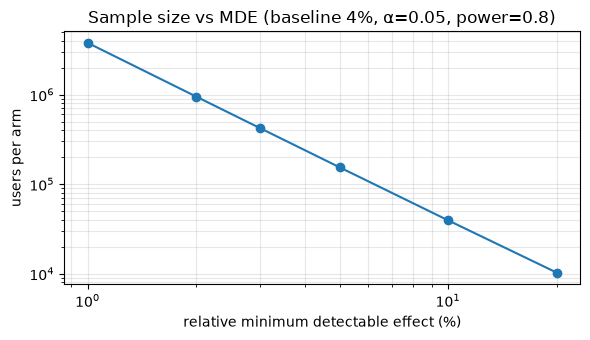

In [13]:
mdes = np.array([0.01, 0.02, 0.03, 0.05, 0.10, 0.20])
sizes = np.array([n_per_arm_statsmodels(p1, p1 * (1 + m)) for m in mdes])
print(pd.DataFrame({"relative MDE": [f"{m:.0%}" for m in mdes], "users per arm": [f"{s:,.0f}" for s in sizes]}).to_string(index=False))
print(f"halving the MDE from 10% to 5% multiplies the sample size by {sizes[3] / sizes[4]:.1f}×")

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(mdes * 100, sizes, marker="o")
ax.set(xscale="log", yscale="log", xlabel="relative minimum detectable effect (%)", ylabel="users per arm",
       title=f"Sample size vs MDE (baseline {p1:.0%}, α=0.05, power=0.8)")
ax.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

**Sample ratio mismatch check.** Suppose a 50/50 test logged these (hypothetical) user counts. A chi-square goodness-of-fit test tells us whether such an imbalance is plausible by chance. Many experimentation teams use a strict threshold such as p < 0.001 for SRM alerts, because the check runs on every experiment.

In [14]:
observed_users = np.array([50_600, 49_400])         # hypothetical counts: control, treatment
expected_users = observed_users.sum() * np.array([0.5, 0.5])
chi2, p_srm = stats.chisquare(observed_users, expected_users)
print(f"chi2 = {chi2:.1f}, p = {p_srm:.2g} → " + ("🚨 SRM: don't trust this test; debug assignment or logging" if p_srm < 0.001 else "no SRM detected"))

chi2 = 14.4, p = 0.00015 → 🚨 SRM: don't trust this test; debug assignment or logging


### ✍️ Your Turn

Using `n_per_arm_statsmodels`, compute the users needed **per arm** to detect a lift from **10% to 10.3%** (α = 0.05, power = 0.8). Store the result in `n_needed`.

In [15]:
n_needed = None  # TODO: your code here
check("n_needed", n_needed, 159_058, rtol=1e-3, hint="n_per_arm_statsmodels(0.10, 0.103)")

⏳ n_needed: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
n_needed = n_per_arm_statsmodels(0.10, 0.103)
check("n_needed", n_needed, 159_058, rtol=1e-3)
```

Even though the baseline rate is higher than before, a 3% relative lift still needs about 159K users per arm.
</details>

> 💡 **Interview angle:** Say the four inputs of a sample-size calculation (baseline rate, MDE, α, power) and that size grows with **1/MDE²**. Then turn users into **days** using traffic. Details at [Statistics & Probability §8 and §14](../01_Core_Scientific_Computing/05_Statistics_and_Probability.ipynb).

**Q13. How long should you run an A/B test, and why is "stop when p < 0.05" wrong?**

<details><summary>Show answer</summary>

- **30-second answer:** Compute the sample size first from the baseline, MDE, α and power, convert it to days, and round up to whole weeks. Stopping at the first significant p-value (**peeking**) inflates the false-positive rate far above 5%, because you get many chances to see a random fluctuation.
- **Go deeper:** If you must monitor continuously, use sequential testing (for example always-valid p-values or group-sequential boundaries). Watch for **novelty or primacy effects**: the first week can differ from the steady state. Use long-term holdouts for slow-moving metrics like retention.
- **❌ Common wrong answer:** "Run until the result becomes significant."

</details>

**Q14. What guardrail metrics would you set for a new feed-ranking model, and what is a sample ratio mismatch?**

<details><summary>Show answer</summary>

- **30-second answer:** Guardrails: latency p95/p99, error rate, crash rate, hides and reports, unsubscribes, content diversity or creator exposure, and revenue if ads are in the feed. SRM is when the observed split of users between arms differs significantly from the designed split. It signals broken assignment, bot filtering or logging, so the results can't be trusted.
- **Go deeper:** Guardrails need their own power analysis (a latency regression may need fewer users to detect). Define **before** the test which guardrail changes block a launch. Check SRM overall and per segment (for example per app version).
- **❌ Common wrong answer:** "If the primary metric is significantly positive, ship it."

</details>

**Q15. Why might you use interleaving instead of an A/B test for a ranking change?**

<details><summary>Show answer</summary>

- **30-second answer:** Interleaving shows each user **one merged list** built from both rankers and credits the ranker whose items get clicked. Each user compares both rankers at once, so the between-user noise cancels out. Interleaving typically needs much less traffic to detect which ranker users prefer, which makes it great for quickly screening many ranking candidates.
- **Go deeper:** It measures **preference**, not business impact (revenue, retention), so winners still go through a regular A/B test. Team-draft interleaving is a common variant that avoids bias toward one ranker.
- **❌ Common wrong answer:** "Interleaving replaces A/B tests entirely."

</details>

## 7. Monitoring, Iteration, Scaling, and Failure Modes 🟡

### What to monitor

| Layer | Signals | Example alert |
|---|---|---|
| **System** | QPS, latency p50/p95/p99, errors, timeouts, CPU/GPU, cache hit rate | p99 > SLO for 10 minutes |
| **Data** | Schema, null rates, value ranges, feature drift (PSI, KS), freshness of feature pipelines | A feature's null rate jumps from 0.1% to 20% |
| **Model** | Prediction distribution, calibration, performance once labels arrive, slice metrics | Mean predicted fraud score doubles overnight |
| **Business** | CTR, conversion, fraud losses, complaints | Conversion down 5% vs last week, same weekday |

Full detail and code: [Model Monitoring & Drift](../09_MLOps/05_Model_Monitoring_and_Drift.ipynb).

### Iterate with error analysis

Look at the worst mistakes by slice (new users, long-tail items, specific countries), add features or data for the biggest bucket, and re-evaluate. Iteration speed (days per experiment) is a competitive advantage. Say it in interviews.

### Scaling playbook

| Pressure | Levers |
|---|---|
| More QPS | Stateless model servers behind a load balancer + autoscaling; caching; precompute heavy parts |
| More items | ANN indices, sharding, two-stage retrieval, pre-filtering |
| Bigger models | Distillation, quantization, GPU batching, a cheap pre-ranker that cuts candidates |
| More training data | Negative downsampling (with calibration correction), distributed training, incremental training |

### Failure modes and graceful degradation

```mermaid
flowchart LR
    R["Request"] --> P["Personalized ranker"]
    P -->|"timeout or error"| C["Cached recommendations from the last batch run"]
    C -->|"cache miss"| G["Popular in region, precomputed"]
    G -->|"unavailable"| S["Static editorial list"]
```

| Failure | Detection | Response |
|---|---|---|
| Feature store slow or down | Timeouts, null-rate monitors | Defaults the model was **trained** with, or fall back to a simpler model |
| Bad model deployed | Canary metrics, prediction-distribution shift | Automatic rollback to the previous registered version |
| Upstream data bug | Validation gates in the training pipeline | Block training, alert, keep the current model |
| Traffic spike | Autoscaling metrics, queue depth | Load shedding, serve cached or popular results |
| Feedback loop / popularity collapse | Diversity and coverage metrics | Exploration traffic, re-ranking for diversity (Section 13) |
| Adversaries adapt (fraud, spam) | Rising losses in newest labels, new feature patterns | Faster retraining, rules for new patterns, human review |

**Q16. The online feature store times out for 2% of requests. How should the ranking service behave?**

<details><summary>Show answer</summary>

- **30-second answer:** Never fail the whole request. Set a strict timeout, then (1) use default values that the model saw during training for missing features, **or** (2) route to a fallback model that doesn't need those features, **or** (3) serve cached or popular results. Log that a fallback happened and alert if the rate grows.
- **Go deeper:** Train with feature dropout or explicit "missing" indicators, so missing values at serving time are in-distribution. Track the fallback rate as a guardrail in A/B tests: a new model that needs more features may time out more often.
- **❌ Common wrong answer:** "Fill missing features with 0." If the model never saw zeros in training, predictions become arbitrary.

</details>

**Q17. How would you notice that a model is silently degrading when labels arrive weeks later?**

<details><summary>Show answer</summary>

- **30-second answer:** Monitor **leading indicators** that don't need labels: input feature drift, prediction-score distribution, the share of predictions above the decision threshold, and business proxies (manual review hit rate, early customer complaints). Then confirm with delayed performance metrics once labels mature.
- **Go deeper:** Keep a small randomly sampled stream sent to human review for fast labels. Compare the live model with a shadow model trained on newer data. Drift alone isn't proof of degradation, so tie alerts to an estimated business impact.
- **❌ Common wrong answer:** "Wait until the monthly accuracy report."

</details>

**Q18. Traffic will grow 10× next year. What changes in your design?**

<details><summary>Show answer</summary>

- **30-second answer:** Re-run the capacity estimate. Scale stateless services horizontally, and cache and precompute more. Shard the ANN index and feature store. Reduce per-request cost with a cheaper pre-ranker, distillation or quantization. Revisit the training pipeline, because 10× more logs usually needs negative downsampling or distributed training.
- **Go deeper:** Look for **super-linear** costs: all-pairs features, fan-out to more shards (tail latency), and storage of impression logs. Also consider multi-region serving for latency and resilience.
- **❌ Common wrong answer:** "Buy 10× more servers." That ignores the components that don't scale linearly.

</details>

## 8. Building Block: Two-Stage Retrieval and Ranking 🟡

You can't run an expensive model on every item for every request. Most large recommenders and search engines therefore work like a **funnel**:

```mermaid
flowchart LR
    A[("Corpus: millions of items")] --> B["Candidate generation: cheap, high recall, several sources"]
    B -->|"hundreds to thousands"| C["Ranking: expensive model, many features"]
    C -->|"tens to hundreds"| D["Re-ranking: diversity, freshness, business rules"]
    D -->|"what the user sees"| E["Feed or results page"]
```

- **Candidate generation** (retrieval) must be fast and have high **recall**: an item it misses can never be shown. Typical sources are embedding nearest neighbours, "similar to what you watched", popular or trending items, follows or subscriptions, and fresh items.
- **Ranking** uses a richer model and features for **precision** at the top of the list.
- **Re-ranking** applies constraints: deduplication, diversity, fairness to creators, and policy filters.

### Demo: a mini two-stage recommender on MovieLens

**Setup, explained honestly.** The gold standard is a **global time split** (train before date *T*, test after). In this small dataset, though, most users are active only in short bursts. The cell below counts how many users rated movies both before and after 1 January 2017. Because so few do, we use a **per-user chronological split** instead: each user's first 60% of ratings are `history`, the next 20% are the `label_window` (used to train the ranker), and the last 20% are the `test_window`. One caveat: the embeddings see other users' later ratings, so absolute numbers are slightly optimistic. The *comparisons* between methods are still fair.

In [16]:
movies = pd.read_csv(DATA_DIR / "movies.csv")
rs = ratings.sort_values(["userId", "rated_at", "movieId"], ignore_index=True)
position_in_user = rs.groupby("userId").cumcount()
user_total = rs.groupby("userId")["movieId"].transform("size")
rs["period"] = np.select([position_in_user < 0.6 * user_total, position_in_user < 0.8 * user_total],
                         ["history", "label_window"], default="test_window")

users_both_sides = len(set(rs.loc[rs["rated_at"] < CUTOFF, "userId"]) & set(rs.loc[rs["rated_at"] >= CUTOFF, "userId"]))
print(f"users active both before and after {CUTOFF:%Y-%m-%d}: {users_both_sides} of {rs['userId'].nunique()} → too few for a global split")
print(rs["period"].value_counts().to_string())

item_ids, user_ids = np.sort(rs["movieId"].unique()), np.sort(rs["userId"].unique())
rs["i"], rs["u"] = np.searchsorted(item_ids, rs["movieId"]), np.searchsorted(user_ids, rs["userId"])
N_USERS, N_ITEMS = len(user_ids), len(item_ids)
meta = movies.set_index("movieId").reindex(item_ids)
genre_matrix = meta["genres"].str.get_dummies("|").to_numpy(dtype=float)            # (items, genres)
release_year = meta["title"].str.extract(r"\((\d{4})\)\s*$")[0].astype(float).to_numpy()
print(f"{N_USERS} users × {N_ITEMS:,} items | {genre_matrix.shape[1]} genre columns")

users active both before and after 2017-01-01: 28 of 610 → too few for a global split
period
history         60732
label_window    20164
test_window     19940
610 users × 9,724 items | 20 genre columns


**Stage 1 — candidate generation** from two cheap sources, each computed **only from the history rows**:

1. **Embedding retrieval.** Truncated SVD (a matrix factorization) of the user × item interaction matrix gives each user and item a 64-number vector. Candidates are the items with the highest dot product with the user vector (exact search here; Section 9 shows approximate search).
2. **Popularity.** The most-watched items the user hasn't seen.

In [17]:
def generate_candidates(history, n_candidates=100, n_factors=64):
    """Return the top-n unseen items per user from two sources, best first, using only `history`."""
    X = csr_matrix((np.ones(len(history)), (history["u"], history["i"])), shape=(N_USERS, N_ITEMS))
    svd = TruncatedSVD(n_components=n_factors, random_state=0).fit(X)
    user_vecs, item_vecs = svd.transform(X), svd.components_.T                     # (users, f), (items, f)
    seen = X.toarray() > 0
    emb_scores = user_vecs @ item_vecs.T
    emb_scores[seen] = -np.inf                                                     # never recommend what they watched
    item_count = np.asarray(X.sum(axis=0)).ravel()
    pop_scores = np.where(seen, -np.inf, item_count[None, :].astype(float))

    def top_n(scores):
        part = np.argpartition(-scores, n_candidates, axis=1)[:, :n_candidates]  # O(items) per user
        order = np.argsort(-np.take_along_axis(scores, part, axis=1), axis=1)
        return np.take_along_axis(part, order, axis=1)

    return dict(emb_scores=emb_scores, emb_top=top_n(emb_scores), pop_top=top_n(pop_scores),
                item_count=item_count, seen=seen)


def targets_of(df):
    """{user index: set of item indices the user interacted with in this window}"""
    return df.groupby("u")["i"].agg(set).to_dict()


hist_1, targ_1 = rs[rs["period"] == "history"], targets_of(rs[rs["period"] == "label_window"])
hist_2, targ_2 = rs[rs["period"] != "test_window"], targets_of(rs[rs["period"] == "test_window"])

start = time.perf_counter()
cands_1, cands_2 = generate_candidates(hist_1), generate_candidates(hist_2)
print(f"candidate generation for all users, two stages: {time.perf_counter() - start:.1f} s")

rows = []
for k in (10, 50, 100):
    rows.append({
        "k": k,
        "embedding recall@k": np.mean([len(set(cands_2["emb_top"][u][:k]) & t) / len(t) for u, t in targ_2.items()]),
        "popularity recall@k": np.mean([len(set(cands_2["pop_top"][u][:k]) & t) / len(t) for u, t in targ_2.items()]),
    })
union_recall = np.mean([len(set(np.union1d(cands_2["emb_top"][u], cands_2["pop_top"][u])) & t) / len(t) for u, t in targ_2.items()])
cold_share = np.mean([np.mean([cands_2["item_count"][i] == 0 for i in t]) for t in targ_2.values()])
print(pd.DataFrame(rows).round(3).to_string(index=False))
print(f"\nunion of both sources (≤200 candidates) recall: {union_recall:.3f}")
print(f"share of test items never seen in anyone's history (cold-start items no retriever can find): {cold_share:.1%}")

candidate generation for all users, two stages: 0.3 s
  k  embedding recall@k  popularity recall@k
 10               0.065                0.040
 50               0.229                0.129
100               0.339                0.200

union of both sources (≤200 candidates) recall: 0.399
share of test items never seen in anyone's history (cold-start items no retriever can find): 3.6%


Two lessons are visible in the numbers:

1. **Recall grows with k, and the two sources complement each other:** their union (at most 200 items) finds more of the test items than either top-100 list alone. That's why real systems merge several candidate generators.
2. **Candidate recall is a ceiling for the whole system.** If an item the user will watch isn't in the candidate set, no ranker can bring it back.

**Stage 2 — ranking.** We train a gradient-boosted classifier to predict "will the user watch this candidate?". To stay leakage-free, the ranker learns from candidates generated from `history`, labelled with the `label_window`. It is then evaluated on candidates generated from `history + label_window`, labelled with the `test_window`, a period it never saw. Features combine retrieval signals with item and user context.

In [18]:
FEATURES = ["emb_score", "emb_rank", "pop_rank", "log_item_count", "item_mean_rating", "genre_match", "year_gap", "user_history_len"]


def ranking_features(history, cands, targets):
    """One row per (user, candidate) with features built from `history` only, and the label from `targets`."""
    counts = np.bincount(history["i"], minlength=N_ITEMS)
    item_mean = np.bincount(history["i"], weights=history["rating"], minlength=N_ITEMS) / np.where(counts > 0, counts, np.nan)
    X = csr_matrix((np.ones(len(history)), (history["u"], history["i"])), shape=(N_USERS, N_ITEMS))
    profile = np.asarray(X @ genre_matrix)
    profile /= np.maximum(np.linalg.norm(profile, axis=1, keepdims=True), 1e-9)
    genre_unit = genre_matrix / np.maximum(np.linalg.norm(genre_matrix, axis=1, keepdims=True), 1e-9)
    user_year = (history.assign(year=release_year[history["i"]]).groupby("u")["year"].median()
                 .reindex(range(N_USERS)).to_numpy())
    frames = []
    for u, relevant in targets.items():
        emb_list, pop_list = cands["emb_top"][u], cands["pop_top"][u]
        cand = np.union1d(emb_list, pop_list)
        emb_rank = {item: r for r, item in enumerate(emb_list)}
        pop_rank = {item: r for r, item in enumerate(pop_list)}
        frames.append(pd.DataFrame({
            "u": u, "i": cand,
            "emb_score": cands["emb_scores"][u, cand],
            "emb_rank": [emb_rank.get(x, len(emb_list)) for x in cand],       # len(list) = "not retrieved by this source"
            "pop_rank": [pop_rank.get(x, len(pop_list)) for x in cand],
            "log_item_count": np.log1p(counts[cand]),
            "item_mean_rating": item_mean[cand],
            "genre_match": genre_unit[cand] @ profile[u],
            "year_gap": release_year[cand] - user_year[u],
            "user_history_len": cands["seen"][u].sum(),
            "label": np.isin(cand, list(relevant)).astype(int),
        }))
    return pd.concat(frames, ignore_index=True)


start = time.perf_counter()
train_rank = ranking_features(hist_1, cands_1, targ_1)
test_rank = ranking_features(hist_2, cands_2, targ_2)
ranker = HistGradientBoostingClassifier(max_iter=200, learning_rate=0.05, random_state=0)
ranker.fit(train_rank[FEATURES], train_rank["label"])
test_rank["ranker_score"] = ranker.predict_proba(test_rank[FEATURES])[:, 1]
print(f"ranker train rows {len(train_rank):,} (positives {train_rank['label'].mean():.1%}) | "
      f"test rows {len(test_rank):,} | built and trained in {time.perf_counter() - start:.1f} s")


def metrics_at_k(df, score_col, targets, k=10):
    """Mean recall@k and NDCG@k over users; the denominator counts ALL relevant items, not just retrieved ones."""
    discounts = 1 / np.log2(np.arange(2, k + 2))
    recalls, ndcgs = [], []
    for u, group in df.groupby("u", sort=False):
        top = group.nlargest(k, score_col)["label"].to_numpy()
        n_relevant = len(targets[u])
        recalls.append(top.sum() / n_relevant)
        ndcgs.append((top * discounts[:len(top)]).sum() / discounts[:min(n_relevant, k)].sum())
    return np.mean(recalls), np.mean(ndcgs)


orderings = {"popularity only": "log_item_count", "embedding score only": "emb_score", "learned ranker (GBDT)": "ranker_score"}
table = pd.DataFrame([(name, *metrics_at_k(test_rank, col, targ_2)) for name, col in orderings.items()],
                     columns=["order the same candidates by", "recall@10", "NDCG@10"]).set_index("order the same candidates by")
print(table.round(4).to_string())
best = table["NDCG@10"].idxmax()
lift = table.loc["learned ranker (GBDT)", "NDCG@10"] / table.loc["embedding score only", "NDCG@10"] - 1
print(f"\n→ best ordering: {best} | ranker vs embedding score: {lift:+.1%} NDCG@10 on the held-out test window")

ranker train rows 103,492 (positives 5.4%) | test rows 103,044 | built and trained in 3.6 s


                              recall@10  NDCG@10
order the same candidates by                    
popularity only                  0.0398   0.0867
embedding score only             0.0645   0.1071
learned ranker (GBDT)            0.0704   0.1196

→ best ordering: learned ranker (GBDT) | ranker vs embedding score: +11.7% NDCG@10 on the held-out test window


The funnel works as designed: cheap retrievers find the few hundred plausible items, and a model that sees more signals orders them. The absolute numbers are small because the task is hard: predicting exactly which of ~9,700 movies someone rates next from a tiny dataset. In an interview, what matters is the **structure**: measure candidate recall separately from ranking quality, and never let the ranker train on labels from the period you evaluate on.

### ✍️ Your Turn

A retriever returned `candidates = [4, 8, 15, 16, 23, 42]`, and the user's relevant items are `{8, 42, 99, 7}`. What is the **best possible** recall@1 and recall@10 that a *perfect* ranker could reach on this candidate set? Store them as a tuple `(ceiling_at_1, ceiling_at_10)` in `recall_ceilings`.

In [19]:
candidates_toy, relevant_toy = [4, 8, 15, 16, 23, 42], {8, 42, 99, 7}
recall_ceilings = None  # TODO: your code here
check("recall_ceilings", recall_ceilings, (0.25, 0.5),
      hint="A perfect ranker puts retrieved relevant items first: min(#retrieved relevant, k) / #relevant.")

⏳ recall_ceilings: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
candidates_toy, relevant_toy = [4, 8, 15, 16, 23, 42], {8, 42, 99, 7}
hits = len(set(candidates_toy) & relevant_toy)                 # 2 relevant items were retrieved
recall_ceilings = (min(hits, 1) / len(relevant_toy), min(hits, 10) / len(relevant_toy))
check("recall_ceilings", recall_ceilings, (0.25, 0.5))
```

Items 99 and 7 were never retrieved, so even a perfect ranker can't exceed 50% recall. This is why you evaluate candidate generation on its own.
</details>

> 💡 **Interview angle:** "Retrieval optimizes **recall** under a tight compute budget; ranking optimizes **precision at the top** with a richer model; re-ranking enforces **business constraints**." Then state candidate counts from your latency budget.

**Q19. Why do recommendation systems use a two-stage (retrieval + ranking) architecture, and how do you choose the number of candidates?**

<details><summary>Show answer</summary>

- **30-second answer:** Scoring millions of items with a feature-rich model per request is far too slow and expensive. A cheap retrieval stage (ANN over embeddings, co-occurrence, popularity) narrows the set to hundreds or thousands with high recall, and the expensive ranker only scores those. The candidate count is a trade-off: more candidates raise recall (and the quality ceiling) but cost ranking latency. Pick it with the latency budget and a **recall@k vs k curve**.
- **Go deeper:** Large systems add a light **pre-ranker** between the stages, and merge several retrieval sources with per-source quotas. The YouTube recommendations paper (Covington et al., 2016) is the classic description of this split.
- **❌ Common wrong answer:** "Two stages exist because one model can't be accurate enough." The reason is **compute and latency**, not accuracy.

</details>

**Q20. How do you evaluate the candidate generation stage separately from the ranker?**

<details><summary>Show answer</summary>

- **30-second answer:** Measure **recall@k** (or hit rate@k) of the candidate set against items the user later engaged with, on a future time window, for several values of k and per source. Ranking is evaluated with NDCG/MRR **within** the candidate set, plus end-to-end metrics.
- **Go deeper:** Also track **coverage** (the share of the catalogue ever retrieved), freshness (the share of new items) and each source's unique contribution (recall lost if the source were removed). An improvement in the ranker can be invisible if retrieval recall is the bottleneck.
- **❌ Common wrong answer:** "Only the final metric matters; you can't evaluate stages separately."

</details>

**Q21. Where do the negative examples for training the ranker come from?**

<details><summary>Show answer</summary>

- **30-second answer:** Mostly **impressions without engagement**: items that were shown (so the user had a chance to act) but not clicked or watched. Train on the **candidates the retrieval stage produces**, so the ranker learns to separate items it will actually be asked about.
- **Go deeper:** For retrieval models (two-tower), use in-batch or random negatives, and correct for sampling bias, because popular items appear more often as in-batch negatives (Yi et al., 2019). Beware position bias: an unclicked item at position 40 was probably never seen (Section 13). Hard negatives improve precision but can include false negatives.
- **❌ Common wrong answer:** "Every item the user didn't click is a negative." Items that were never shown aren't evidence of dislike.

</details>

## 9. Building Block: Embeddings and Approximate Nearest Neighbours 🟡

An **embedding** is a vector that places similar things close together. A **two-tower model** learns a user (or query) tower and an item tower whose dot product predicts engagement. Item vectors are pre-computed and indexed. At request time you compute one user vector and search for the nearest item vectors.

Exact search compares against **every** item: fine for 100K items, too slow for 100M items at thousands of QPS. **Approximate nearest neighbour (ANN)** indices trade a little recall for large speed and memory savings:

| Index | Idea | Strengths | Weaknesses |
|---|---|---|---|
| **Flat** | Compare with every vector | Exact, no training | O(N) per query |
| **IVF** | Cluster vectors; search only the `nprobe` nearest clusters | Fast, tunable, memory ≈ flat | Needs training; recall drops for small `nprobe` |
| **HNSW** | Multi-layer proximity graph; greedy walk toward the query | Excellent recall/latency; incremental inserts | Extra memory for graph links; deletes are awkward |
| **PQ (product quantization)** | Compress each vector to a few bytes | 10–100× less memory | Lossy: lower recall unless you re-rank with full vectors |

### Measured trade-offs with FAISS

To see the trade-offs we need a *controlled* benchmark, so this uses **synthetic** clustered vectors (100K items × 64 dims, normalized): real embeddings are also clustered. Timings are from this machine, averaged over a batch of 1,000 queries using all CPU threads. Your numbers will differ, but the *shape* of the trade-off is what matters. The embeddings notebook runs FAISS on real text embeddings: [Embeddings and Semantic Search §11](../05_NLP/02_Embeddings_and_Semantic_Search.ipynb).

In [20]:
ann_rng = np.random.default_rng(0)
n_vectors, dim, n_clusters, k_nn = 100_000, 64, 200, 10
centers = ann_rng.normal(size=(n_clusters, dim)).astype("float32")
vectors = (centers[ann_rng.integers(0, n_clusters, n_vectors)] + 0.6 * ann_rng.normal(size=(n_vectors, dim))).astype("float32")
queries = (centers[ann_rng.integers(0, n_clusters, 1_000)] + 0.6 * ann_rng.normal(size=(1_000, dim))).astype("float32")
vectors /= np.linalg.norm(vectors, axis=1, keepdims=True)
queries /= np.linalg.norm(queries, axis=1, keepdims=True)


def timed_search(index, label):
    start = time.perf_counter()
    _, found = index.search(queries, k_nn)
    ms_per_query = (time.perf_counter() - start) / len(queries) * 1000
    recall = np.mean([len(set(a) & set(b)) / k_nn for a, b in zip(found, exact_ids)])
    return {"index": label, "recall@10": recall, "ms/query": ms_per_query}


def index_mb(index):
    return faiss.serialize_index(index).nbytes / 1e6


flat = faiss.IndexFlatIP(dim)
flat.add(vectors)
_, exact_ids = flat.search(queries, k_nn)                        # ground truth
results = [timed_search(flat, "Flat (exact)")]

hnsw = faiss.IndexHNSWFlat(dim, 32, faiss.METRIC_INNER_PRODUCT)
hnsw.hnsw.efConstruction = 64
hnsw.add(vectors)
for ef in (16, 64):
    hnsw.hnsw.efSearch = ef
    results.append(timed_search(hnsw, f"HNSW M=32 efSearch={ef}"))

ivf = faiss.IndexIVFFlat(faiss.IndexFlatIP(dim), dim, 1024, faiss.METRIC_INNER_PRODUCT)
ivf.train(vectors)
ivf.add(vectors)
for nprobe in (1, 8, 32):
    ivf.nprobe = nprobe
    results.append(timed_search(ivf, f"IVF 1024 lists nprobe={nprobe}"))

ivfpq = faiss.IndexIVFPQ(faiss.IndexFlatIP(dim), dim, 1024, 16, 8, faiss.METRIC_INNER_PRODUCT)   # 16 bytes per vector
ivfpq.train(vectors)
ivfpq.add(vectors)
ivfpq.nprobe = 32
results.append(timed_search(ivfpq, "IVF-PQ 16 bytes nprobe=32"))

sizes_mb = {"Flat": index_mb(flat), "HNSW": index_mb(hnsw), "IVF": index_mb(ivf), "IVF-PQ": index_mb(ivfpq)}
ann_table = pd.DataFrame(results)
ann_table["index size (MB)"] = [sizes_mb[next(key for key in ("IVF-PQ", "HNSW", "IVF", "Flat") if label.startswith(key))]
                                for label in ann_table["index"]]
print(ann_table.round({"recall@10": 3, "ms/query": 4, "index size (MB)": 1}).to_string(index=False))

                    index  recall@10  ms/query  index size (MB)
             Flat (exact)      1.000    0.0416             25.6
    HNSW M=32 efSearch=16      0.927    0.0015             52.8
    HNSW M=32 efSearch=64      0.998    0.0029             52.8
  IVF 1024 lists nprobe=1      0.396    0.0106             26.7
  IVF 1024 lists nprobe=8      0.998    0.0087             26.7
 IVF 1024 lists nprobe=32      1.000    0.0094             26.7
IVF-PQ 16 bytes nprobe=32      0.492    0.0108              2.7


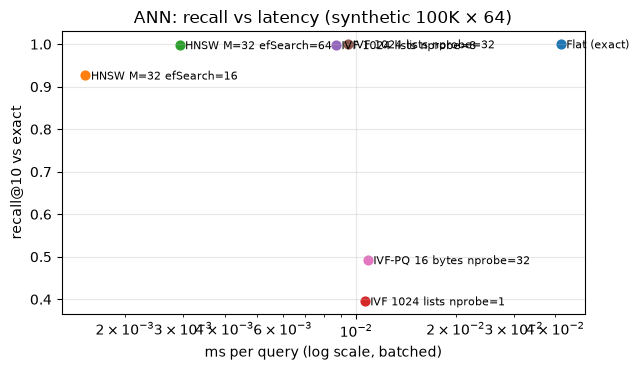

In [21]:
fig, ax = plt.subplots(figsize=(6.5, 3.8))
for _, row in ann_table.iterrows():
    ax.scatter(row["ms/query"], row["recall@10"], s=40)
    ax.annotate(row["index"], (row["ms/query"], row["recall@10"]), fontsize=8, xytext=(4, -3), textcoords="offset points")
ax.set(xscale="log", xlabel="ms per query (log scale, batched)", ylabel="recall@10 vs exact",
       title="ANN: recall vs latency (synthetic 100K × 64)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Memory math you can do on a whiteboard.** A flat float32 index needs `N × d × 4` bytes. HNSW adds roughly `N × 2M × 4` bytes of neighbour ids at its bottom layer (plus a little for upper layers). PQ stores `N × code_bytes`. Let's check the formulas against the FAISS indices we just built, then scale to a realistic catalogue.

In [22]:
flat_formula_mb = n_vectors * dim * 4 / 1e6
hnsw_formula_mb = flat_formula_mb + n_vectors * 2 * 32 * 4 / 1e6
print(f"flat : formula {flat_formula_mb:.1f} MB vs measured {sizes_mb['Flat']:.1f} MB")
print(f"HNSW : formula {hnsw_formula_mb:.1f} MB vs measured {sizes_mb['HNSW']:.1f} MB "
      f"(formula ignores upper layers: {sizes_mb['HNSW'] / hnsw_formula_mb - 1:+.1%})")

catalogue = dict(n_items=200_000_000, embedding_dim=128, bytes_per_float=4, hnsw_M=32, bytes_per_neighbor_id=4, pq_code_bytes=64)
show_assumptions("large catalogue ANN index", catalogue)
flat_bytes = catalogue["n_items"] * catalogue["embedding_dim"] * catalogue["bytes_per_float"]
hnsw_bytes = flat_bytes + catalogue["n_items"] * 2 * catalogue["hnsw_M"] * catalogue["bytes_per_neighbor_id"]
pq_bytes = catalogue["n_items"] * catalogue["pq_code_bytes"]
print(f"flat float32 : {gib(flat_bytes)}")
print(f"HNSW         : {gib(hnsw_bytes)}  → needs sharding across machines")
print(f"PQ 64 bytes  : {gib(pq_bytes)}  → fits on one large machine; re-rank top results with full vectors")

flat : formula 25.6 MB vs measured 25.6 MB
HNSW : formula 51.2 MB vs measured 52.8 MB (formula ignores upper layers: +3.2%)
ASSUMPTIONS — large catalogue ANN index (illustrative: replace with the numbers your interviewer gives)
  n_items               = 200,000,000
  embedding_dim         = 128
  bytes_per_float       = 4
  hnsw_M                = 32
  bytes_per_neighbor_id = 4
  pq_code_bytes         = 64

flat float32 : 95.4 GiB
HNSW         : 143.1 GiB  → needs sharding across machines
PQ 64 bytes  : 11.9 GiB  → fits on one large machine; re-rank top results with full vectors


Notice in the measured table: IVF with `nprobe=1` and IVF-PQ lose a lot of recall. Compression and aggressive pruning aren't free. Tune `efSearch`/`nprobe` on a recall-vs-latency curve like the one above, and re-rank the ANN results with exact scores when you use PQ.

> 💡 **Interview angle:** Quote the memory formula (`N × d × 4 bytes`) and the knobs (`efSearch`, `nprobe`, code size), and say you'd pick the operating point from a **recall@k vs latency** curve measured on your own data.

**Q22. HNSW or IVF-PQ for 500M item embeddings? Justify the choice.**

<details><summary>Show answer</summary>

- **30-second answer:** At 500M items, memory dominates. Flat float32 at 256 dims is ~480 GiB, and HNSW adds graph links on top. IVF-PQ compresses each vector to tens of bytes, so the whole index fits on a few machines, at a recall cost that you recover by **re-ranking the top few hundred results with full vectors** fetched from storage. HNSW is the better choice when memory is affordable (smaller corpus, or sharded) and you need the best recall per millisecond and frequent inserts.
- **Go deeper:** Other options include sharding HNSW by category or region, hybrid on-disk indices (DiskANN-style), and GPU FAISS for high QPS. Filtering (country, availability) matters too: pre-filtering can break graph connectivity, while post-filtering loses results, so check what your vector database supports.
- **❌ Common wrong answer:** "HNSW is always best because it has the highest recall."

</details>

**Q23. You retrained the two-tower model. What can go wrong when you update the ANN index?**

<details><summary>Show answer</summary>

- **30-second answer:** The query tower and the item index must come from the **same model version**. Vectors from different training runs live in different spaces, so mixing them returns garbage. Rebuild the item index with the new item tower, validate recall offline, then switch query encoder and index **atomically** (versioned index + blue/green switch).
- **Go deeper:** New items need embeddings between rebuilds. Use incremental inserts with the current version, or a content-based tower for fresh items. Monitor retrieval recall and the score distribution after the switch, and keep the old index for fast rollback.
- **❌ Common wrong answer:** "Just upsert the new item vectors into the existing index over the next day."

</details>

## 10. Building Block: Real-Time vs Batch Features 🟢

| Freshness | Example features | Typical pipeline | Cost |
|---|---|---|---|
| **Batch** (hours–days) | 30-day genre affinity, item quality score, account age | Warehouse SQL / Spark job → offline + online store | Cheap |
| **Near real-time** (seconds–minutes) | Clicks in this session, card transactions in the last 10 minutes, trending score | Event stream → stream processor → online store | Medium: streaming infrastructure, backfills |
| **Request-time** | Query text, device, time of day, transaction amount | Computed inside the request | Cheap, but adds latency |

```mermaid
flowchart LR
    APP["App events"] --> BUS["Event stream"]
    BUS --> STREAM["Stream processor: windowed counts"]
    BUS --> LAKE[("Data lake / warehouse")]
    LAKE --> BATCH["Daily batch jobs"]
    STREAM --> ONLINE[("Online feature store")]
    BATCH --> ONLINE
    REQ["Request with context"] --> SERVER["Model server"]
    ONLINE --> SERVER
    SERVER --> LOG["Log served features and prediction"]
    LOG --> LAKE
```

A classic real-time feature is **velocity**: "how many transactions did this card make in the last 10 minutes, **not counting this one**?". The toy table below (made-up values chosen to show the mechanics) computes it with a time-based rolling window. `closed="left"` excludes the current event, which is the point-in-time rule again.

In [23]:
txns = pd.DataFrame({
    "card": ["A", "A", "B", "A", "B", "A"],
    "ts": pd.to_datetime(["2026-05-01 10:00", "2026-05-01 10:03", "2026-05-01 10:05",
                          "2026-05-01 10:07", "2026-05-01 10:09", "2026-05-01 10:20"]),
    "amount": [20.0, 35.0, 900.0, 400.0, 15.0, 18.0],
})
parts = []
for card, group in txns.groupby("card"):
    group = group.sort_values("ts")
    window = group.rolling("10min", on="ts", closed="left")["amount"]
    parts.append(group.assign(txns_prev_10min=window.count().fillna(0).astype(int).to_numpy(),
                              amount_prev_10min=window.sum().fillna(0).to_numpy()))
print(pd.concat(parts).sort_values("ts").to_string(index=False))

card                  ts  amount  txns_prev_10min  amount_prev_10min
   A 2026-05-01 10:00:00    20.0                0                0.0
   A 2026-05-01 10:03:00    35.0                1               20.0
   B 2026-05-01 10:05:00   900.0                0                0.0
   A 2026-05-01 10:07:00   400.0                2               55.0
   B 2026-05-01 10:09:00    15.0                1              900.0
   A 2026-05-01 10:20:00    18.0                0                0.0


Card A's 10:07 transaction sees the two earlier ones. Its 10:20 transaction sees none, because 10:07 is exactly 13 minutes earlier and outside the window. In production, a stream processor maintains these counts per card and writes them to the online store. The *same* window definition must generate training data from the event log.

> 💡 **Interview angle:** Real-time features pay off when **recent behaviour changes the answer** (fraud velocity, session intent, trending). Otherwise, batch features are cheaper and more reliable.

**Q24. When are real-time features worth their cost?**

<details><summary>Show answer</summary>

- **30-second answer:** When the value of the prediction decays quickly with stale information: fraud (a burst of card tests within minutes), session-based recommendations (the user just switched from cooking to travel videos), trending content and dynamic pricing. Prove it with an experiment: train the model with features artificially delayed by 1 hour or 1 day and measure the offline loss. If the difference is small, stay batch.
- **Go deeper:** Costs include streaming infrastructure, exactly-once semantics, late and out-of-order events, backfilling history for training, and on-call burden. Middle grounds: micro-batches every few minutes, or request-time features computed from the client's recent actions.
- **❌ Common wrong answer:** "Real-time is always better, so make every feature streaming."

</details>

**Q25. How do you create training data for a streaming feature that didn't exist until today?**

<details><summary>Show answer</summary>

- **30-second answer:** Either **backfill**: replay the historical event log through the *same* window logic to compute point-in-time values for past events. Or **log and wait**: start logging the feature at serving time and train once enough labelled data has accumulated. Backfill is fast but risks mismatching the streaming implementation. Log-and-wait is exactly consistent but slow.
- **Go deeper:** Many teams do both. They backfill to test whether the feature helps offline, then switch training to logged values once available. Frameworks that run the same code in batch and streaming reduce mismatch risk.
- **❌ Common wrong answer:** "Compute today's value and copy it to all historical rows."

</details>

## 11. Building Block: Caching 🟢

Caching trades **freshness for latency and cost**. What you can cache in an ML system:

- **Final results** for popular, non-personalized requests (top search queries, "trending now").
- **Precomputed recommendations** per user from a batch job, refreshed every few hours.
- **Embeddings and features** that change slowly (item embeddings, user long-term profile).
- **Model outputs** for identical inputs (common in LLM apps; see the next notebook).

Key design questions: the **cache key** (the more personalized the key, the lower the hit rate), the **TTL** (how stale is acceptable), **invalidation** on model or item updates, and **stampedes** (many misses at once after expiry).

### How big must the cache be?

Request popularity often follows a heavy-tailed, roughly **Zipf-like** distribution: a few keys get most of the traffic. *Assuming* Zipf with exponent *s*, the hit rate of caching the *C* most popular keys among *N* is $\sum_{r\le C} r^{-s} / \sum_{r\le N} r^{-s}$. The exponent is an assumption: measure your own traffic.

In [24]:
cache = dict(distinct_keys=1_000_000, zipf_exponent=1.0, latency_hit_ms=2.0, latency_miss_ms=80.0)
show_assumptions("result cache for search queries", cache)

ranks = np.arange(1, cache["distinct_keys"] + 1, dtype=float)
weights = ranks ** -cache["zipf_exponent"]
cumulative_share = np.cumsum(weights) / weights.sum()
for cache_size in (1_000, 10_000, 100_000):
    hit_rate = cumulative_share[cache_size - 1]
    avg_ms = hit_rate * cache["latency_hit_ms"] + (1 - hit_rate) * cache["latency_miss_ms"]
    print(f"cache top {cache_size:>7,} keys ({cache_size / cache['distinct_keys']:.1%} of keys) → hit rate {hit_rate:.1%}, mean latency {avg_ms:.1f} ms")



def zipf_hit_rate(cache_size, n_keys, s, chunk=10_000_000):
    """Exact Σ_{r≤C} r^-s / Σ_{r≤N} r^-s, summed in chunks so tens of millions of keys fit in memory."""
    def partial_sum(n):
        return sum(float((np.arange(lo, min(lo + chunk, n + 1), dtype=float) ** -s).sum()) for lo in range(1, n + 1, chunk))
    return partial_sum(cache_size) / partial_sum(n_keys)


print("\nPersonalized keys, e.g. (user, context): many more keys AND a flatter popularity curve (exponents assumed)")
for n_keys, s in ((1_000_000, 1.0), (50_000_000, 1.0), (50_000_000, 0.7)):
    print(f"  100K-entry cache over {human(n_keys):>6} keys, Zipf s={s} → hit rate {zipf_hit_rate(100_000, n_keys, s):.1%}")

ASSUMPTIONS — result cache for search queries (illustrative: replace with the numbers your interviewer gives)
  distinct_keys   = 1,000,000
  zipf_exponent   = 1.0
  latency_hit_ms  = 2.0
  latency_miss_ms = 80.0

cache top   1,000 keys (0.1% of keys) → hit rate 52.0%, mean latency 39.4 ms
cache top  10,000 keys (1.0% of keys) → hit rate 68.0%, mean latency 27.0 ms
cache top 100,000 keys (10.0% of keys) → hit rate 84.0%, mean latency 14.5 ms

Personalized keys, e.g. (user, context): many more keys AND a flatter popularity curve (exponents assumed)
  100K-entry cache over   1.0M keys, Zipf s=1.0 → hit rate 84.0%
  100K-entry cache over  50.0M keys, Zipf s=1.0 → hit rate 66.0%


  100K-entry cache over  50.0M keys, Zipf s=0.7 → hit rate 15.2%


### ✍️ Your Turn

A cache hit takes 2 ms and a miss takes 60 ms. (1) What is the mean latency at an **80%** hit rate? (2) What hit rate do you need for a **20 ms** mean? Store `(mean_latency_ms, required_hit_rate)` in `cache_answer`.

In [25]:
cache_answer = None  # TODO: your code here
check("cache_answer", cache_answer, (13.6, 40 / 58), rtol=1e-4,
      hint="mean = h·hit + (1−h)·miss. Solve 20 = h·2 + (1−h)·60 for h.")

⏳ cache_answer: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
t_hit, t_miss = 2.0, 60.0
mean_latency_ms = 0.8 * t_hit + 0.2 * t_miss                   # 13.6 ms
required_hit_rate = (t_miss - 20.0) / (t_miss - t_hit)          # ≈ 0.690
cache_answer = (mean_latency_ms, required_hit_rate)
check("cache_answer", cache_answer, (13.6, 40 / 58), rtol=1e-4)
```

Caches help the **mean** a lot, but a 30% miss rate still sends 60-ms requests into your **p99**. Size the backend for misses.
</details>

**Q26. Should you cache personalized recommendations? How do you choose the TTL?**

<details><summary>Show answer</summary>

- **30-second answer:** Often yes, as precomputed candidate lists or ranked results per user, refreshed on a schedule or when the user does something significant, plus a short TTL. Choose the TTL by measuring how fast recommendation quality decays with staleness (offline replay or an A/B test of TTLs), and weigh it against compute savings. Keep session-level re-ranking online so fresh context still matters.
- **Go deeper:** Cache the **expensive, slowly changing parts** (candidates, embeddings) and compute cheap, fast-changing parts per request. Invalidate on model deploys and on item removals (policy takedowns must never be served from cache).
- **❌ Common wrong answer:** "Personalized results can't be cached because every request is unique."

</details>

**Q27. 🐛 After a model deploy, the A/B test shows no difference between control and treatment for the first 24 hours. What could be happening?**

<details><summary>Show answer</summary>

- **30-second answer:** A cache is probably serving results computed by the **old** model to the treatment group (TTL 24 h), so both arms see the same recommendations. Include the model version in the cache key, or invalidate caches for the treatment arm, and verify through logs that treatment requests really hit the new model.
- **Go deeper:** Other causes of identical arms: assignment not propagated to the service, a feature flag defaulting to control, or a fallback path triggered by timeouts. Always log `model_version` with every prediction and check its distribution per arm.
- **❌ Common wrong answer:** "The new model has no effect, so stop the test."

</details>

## 12. Building Block: Cold Start 🟢

**Cold start** means the system has little or no interaction data for a new **user**, a new **item**, or a whole new **product**.

| Cold entity | Strategies |
|---|---|
| **New user** | Popular or trending by region, language and time; onboarding questions (pick topics); device and referral context; session-based models that learn from the first few clicks; exploration via bandits |
| **New item** | **Content-based** embeddings from text, image or audio (so the item has a vector before anyone clicks); metadata (creator, category); a guaranteed **exploration budget** of impressions; boosting fresh items in re-ranking |
| **New product** | Heuristics and rules, transfer from similar products, human curation, collect data with deliberate randomization |

In the MovieLens demo (Section 8), some of the items users watched in the test window had **zero** interactions in the history. The cell below prints that share. No collaborative retriever could have found those items; only content features or exploration can.

How much exploration does a new item need? To estimate a CTR near *p* within ±*e* (95% confidence), you need roughly $n = 1.96^2\,p(1-p)/e^2$ impressions. Multiply by the number of new items per day to see the cost.

In [26]:
print(f"cold-start share of test-window items in the MovieLens demo: {cold_share:.1%}")

exploration = dict(expected_ctr=0.05, margin_of_error=0.01, new_items_per_day=10_000)
show_assumptions("exploration budget for new items", exploration)
p, e = exploration["expected_ctr"], exploration["margin_of_error"]
impressions_per_new_item = math.ceil(stats.norm.ppf(0.975) ** 2 * p * (1 - p) / e ** 2)
exploration_impressions = impressions_per_new_item * exploration["new_items_per_day"]
print(f"impressions per new item: {impressions_per_new_item:,}")
print(f"daily exploration impressions: {human(exploration_impressions)} = "
      f"{exploration_impressions / impressions_per_day:.2%} of the {human(impressions_per_day)} daily impressions from Section 2")

cold-start share of test-window items in the MovieLens demo: 3.6%
ASSUMPTIONS — exploration budget for new items (illustrative: replace with the numbers your interviewer gives)
  expected_ctr      = 0.05
  margin_of_error   = 0.01
  new_items_per_day = 10,000

impressions per new item: 1,825
daily exploration impressions: 18.2M = 0.57% of the 3.2B daily impressions from Section 2


> 💡 **Interview angle:** Split cold start into **new users vs new items**, and give one data-free strategy (content embeddings, popularity) plus one data-collecting strategy (exploration) for each.

**Q28. A new creator uploads a great video, but the recommender never shows it, so it never gets clicks. How do you fix this?**

<details><summary>Show answer</summary>

- **30-second answer:** Break the chicken-and-egg loop. (1) Give new items an **exploration budget**: a small, capped share of impressions to users whose interests match the content-based embedding. (2) Use **content features** (title, visual and audio embeddings, creator history) so the ranker can score the item before clicks exist. (3) Quickly update the item's statistics from the exploration traffic.
- **Go deeper:** Bandit methods (Thompson sampling or UCB) spend exploration where uncertainty is highest. Measure the cost of exploration as a guardrail (short-term engagement dip), and its benefit as catalogue coverage and creator retention.
- **❌ Common wrong answer:** "Wait until the video gets views organically."

</details>

**Q29. What do you show a brand-new user on their first visit?**

<details><summary>Show answer</summary>

- **30-second answer:** A **diverse** set of high-quality popular items conditioned on what we do know (country, language, device, time, referral source), optionally after a short onboarding step to pick interests. Then adapt within the session with a model that uses the first few interactions.
- **Go deeper:** Diversity matters because a first page that covers many interests reveals preferences faster. Treat it as an exploration problem, and evaluate with metrics such as day-1 and day-7 retention for new users as a separate slice.
- **❌ Common wrong answer:** "Show the global top-10 most popular items." That's undiversified, and popularity doesn't equal a good first experience.

</details>

## 13. Building Block: Feedback Loops and Position Bias 🔴

An ML system's outputs **create its own future training data**. Items the model ranks high get more impressions, hence more clicks, hence look even better in the next training run. This **feedback loop** can:

- make popular items more popular (rich-get-richer) and starve the long tail;
- lock in the old model's mistakes, because items it underrates are rarely shown, so evidence never corrects it;
- bias offline evaluation toward the logging policy.

**Position bias** is one mechanism: users click the top result more *because it's on top*. Raw click-through rate therefore mixes "how good is this item" with "where did we put it".

### Simulation: naive CTR vs inverse propensity weighting

This is a **synthetic, controlled** example (we need to know the true relevance, which real logs never reveal). Ten items have a true click probability *if examined*. An **old, imperfect model** ranks them, and users examine position *k* with probability 1/*k* (an assumed propensity). We estimate each item's relevance from the logs two ways:

- **naive CTR** = clicks ÷ impressions
- **IPS (inverse propensity scoring)** = mean of click ÷ P(examined at that position), which up-weights clicks at low positions

In [27]:
sim_rng = np.random.default_rng(7)
n_items_sim, n_requests = 10, 200_000
true_relevance = np.round(sim_rng.uniform(0.05, 0.5, n_items_sim), 3)     # P(click | examined)
old_model_error = sim_rng.normal(0, 0.15, n_items_sim)                    # the logging model is wrong about some items
scores = true_relevance + old_model_error + sim_rng.normal(0, 0.05, (n_requests, n_items_sim))
position = np.argsort(np.argsort(-scores, axis=1), axis=1)                # 0 = top slot
propensity = 1.0 / (position + 1)                                         # ASSUMED examination probability
clicks = sim_rng.random((n_requests, n_items_sim)) < propensity * true_relevance

naive_ctr = clicks.mean(axis=0)
ips_estimate = (clicks / propensity).mean(axis=0)


def top3(values):
    return set(np.argsort(-values)[:3].tolist())


comparison = pd.DataFrame({
    "true relevance": true_relevance, "avg position (1=top)": position.mean(axis=0) + 1,
    "naive CTR": naive_ctr, "IPS estimate": ips_estimate,
}).round(3)
print(comparison.sort_values("true relevance", ascending=False).to_string())
for name, est in (("naive CTR", naive_ctr), ("IPS", ips_estimate)):
    rho = stats.spearmanr(est, true_relevance).statistic
    print(f"{name:9s}: Spearman vs truth {rho:.3f} | true top-3 recovered {len(top3(est) & top3(true_relevance))}/3 | "
          f"mean abs error {np.abs(est - true_relevance).mean():.3f}")

   true relevance  avg position (1=top)  naive CTR  IPS estimate
1           0.454                 1.894      0.279         0.454
5           0.443                 1.342      0.374         0.444
7           0.420                 4.579      0.097         0.429
8           0.409                 7.059      0.058         0.407
2           0.399                 3.501      0.123         0.396
0           0.331                 3.694      0.097         0.331
9           0.261                 7.947      0.033         0.260
4           0.185                 6.264      0.030         0.186
3           0.151                 8.734      0.017         0.151
6           0.052                 9.987      0.005         0.053
naive CTR: Spearman vs truth 0.927 | true top-3 recovered 2/3 | mean abs error 0.199
IPS      : Spearman vs truth 1.000 | true top-3 recovered 3/3 | mean abs error 0.002


Naive CTR **under-states** every item's relevance, and it mis-orders items that the old model placed badly. Training on it would copy the old model's mistakes. IPS recovers the true values, **if** the propensities are right. In practice you estimate propensities with small randomization experiments (for example, randomly swapping adjacent results for a sliver of traffic).

**Other mitigations:** add **position as a training feature** and set it to a fixed value (for example, position 1) at serving time; reserve a small **exploration** slice of traffic with randomized rankings; monitor **catalogue coverage** and diversity; and use counterfactual (off-policy) evaluation.

### ✍️ Your Turn

One item was shown 10 times at these positions (1 = top), with these clicks. Using propensity = 1/position, compute the naive CTR and the IPS estimate. Store `(naive, ips)` in `ips_answer`.

In [28]:
positions_toy = np.array([1, 1, 2, 2, 3, 3, 4, 4, 5, 5])
clicks_toy = np.array([1, 0, 0, 1, 0, 0, 0, 0, 0, 0])
ips_answer = None  # TODO: your code here
check("ips_answer", ips_answer, (0.2, 0.3), hint="IPS = mean(click / propensity) = mean(click * position) here.")

⏳ ips_answer: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
positions_toy = np.array([1, 1, 2, 2, 3, 3, 4, 4, 5, 5])
clicks_toy = np.array([1, 0, 0, 1, 0, 0, 0, 0, 0, 0])
naive = clicks_toy.mean()                                         # 2 / 10
ips = (clicks_toy / (1 / positions_toy)).mean()                   # (1·1 + 1·2) / 10
ips_answer = (naive, ips)
check("ips_answer", ips_answer, (0.2, 0.3))
```

The click at position 2 counts double because only half of users look there. With few impressions, IPS has **high variance**; production systems often clip large weights.
</details>

> 💡 **Interview angle:** Whenever you train on clicks, say "**clicks are biased by what we showed and where**", then name one correction (IPS, position feature, randomized exploration).

**Q30. How does using position as a feature help with position bias?**

<details><summary>Show answer</summary>

- **30-second answer:** During training, the model can attribute part of each click to the position it was shown at, so the other features learn **position-independent** relevance. At serving time, you don't know the final position yet, so you set the position feature to a constant (for example, 1) for all candidates. Ranking then reflects relevance alone.
- **Go deeper:** A popular variant is a separate shallow "bias tower" that takes position and device, whose output is added to the main logit in training and dropped at serving. It works best when positions vary for the same item across impressions. Interactions between position and other features can leak bias back in.
- **❌ Common wrong answer:** "Drop clicks from low positions." That discards data and doesn't remove the bias from the top positions.

</details>

**Q31. How would you detect and dampen a harmful feedback loop in a recommender?**

<details><summary>Show answer</summary>

- **30-second answer:** Detect it with **concentration metrics** over time: the share of impressions going to the top 1% of items, catalogue coverage, Gini of exposure, the share of recommendations from a user's single dominant topic, and falling engagement for fresh items. Dampen it with exploration traffic, diversity constraints in re-ranking, debiased training (IPS or position features), and a **holdout** that isn't influenced by the model.
- **Go deeper:** Keep a small uniformly randomized or "old-policy" holdout to measure what the loop is doing, and use off-policy evaluation to test new policies on logged data. Long-term metrics (retention, creator retention) reveal harm that short-term CTR hides.
- **❌ Common wrong answer:** "Feedback loops are fine: the model is learning what users like."

</details>

## 14. Building Block: Class Imbalance and Label Delay 🟡

### Why accuracy lies when positives are rare

With **prevalence** π (the share of positives), recall *R* and false-positive rate *FPR*, **precision = R·π / (R·π + FPR·(1−π))** (Bayes' rule). Even a model with an excellent-looking 1% FPR produces mostly false alarms when positives are rare:

In [29]:
recall_assumed, fpr_assumed = 0.80, 0.01
print(f"ASSUMED model: recall {recall_assumed:.0%}, false-positive rate {fpr_assumed:.0%}")
for prevalence in (0.20, 0.05, 0.01, 0.001):
    precision = recall_assumed * prevalence / (recall_assumed * prevalence + fpr_assumed * (1 - prevalence))
    accuracy = recall_assumed * prevalence + (1 - fpr_assumed) * (1 - prevalence)
    all_negative_accuracy = 1 - prevalence
    print(f"prevalence {prevalence:6.1%} → precision {precision:6.1%} | accuracy {accuracy:6.2%} "
          f"(a model that always says 'no' scores {all_negative_accuracy:6.2%})")

ASSUMED model: recall 80%, false-positive rate 1%
prevalence  20.0% → precision  95.2% | accuracy 95.20% (a model that always says 'no' scores 80.00%)
prevalence   5.0% → precision  80.8% | accuracy 98.05% (a model that always says 'no' scores 95.00%)
prevalence   1.0% → precision  44.7% | accuracy 98.81% (a model that always says 'no' scores 99.00%)
prevalence   0.1% → precision   7.4% | accuracy 98.98% (a model that always says 'no' scores 99.90%)


Use **PR-AUC**, **recall at a fixed precision or FPR**, and above all **expected cost** (Case Study 17), not accuracy.

### Negative downsampling breaks calibration, and one formula fixes it

With billions of negatives, teams often train on all positives plus a **fraction *w*** of negatives. The model then over-predicts. He et al. (2014, Facebook ads) give the correction $q = \dfrac{p}{p + (1-p)/w}$, where *p* is the prediction of the downsampled model. The demo uses **synthetic** data (`make_classification` with 1% positives), so the true base rate is known.

In [30]:
X_imb, y_imb = make_classification(n_samples=300_000, n_features=20, n_informative=8, weights=[0.99], flip_y=0, random_state=0)
X_tr, X_te, y_tr, y_te = train_test_split(X_imb, y_imb, test_size=0.3, stratify=y_imb, random_state=0)

w = 0.10                                                          # keep 10% of negatives
keep = (y_tr == 1) | (np.random.default_rng(0).random(len(y_tr)) < w)
full_model = LogisticRegression(max_iter=2000).fit(X_tr, y_tr)
down_model = LogisticRegression(max_iter=2000).fit(X_tr[keep], y_tr[keep])

p_full = full_model.predict_proba(X_te)[:, 1]
p_down = down_model.predict_proba(X_te)[:, 1]
p_corrected = p_down / (p_down + (1 - p_down) / w)

print(f"training rows: full {len(y_tr):,} → downsampled {keep.sum():,} ({keep.sum() / len(y_tr):.0%})")
print(f"true test prevalence          : {y_te.mean():.4f}")
for name, pred in (("full data model", p_full), ("downsampled, raw", p_down), ("downsampled, corrected", p_corrected)):
    print(f"{name:24s}: mean prediction {pred.mean():.4f} | log loss {log_loss(y_te, pred):.4f} | AUC {roc_auc_score(y_te, pred):.4f}")

training rows: full 210,000 → downsampled 23,019 (11%)
true test prevalence          : 0.0100
full data model         : mean prediction 0.0100 | log loss 0.0136 | AUC 0.9925
downsampled, raw        : mean prediction 0.0256 | log loss 0.0282 | AUC 0.9933
downsampled, corrected  : mean prediction 0.0099 | log loss 0.0138 | AUC 0.9933


The ranking quality (AUC) is essentially unchanged by downsampling, but the raw probabilities are inflated (compare the mean predictions). That would wreck anything that uses probabilities as numbers, such as bids or expected-cost thresholds. For small probabilities the odds are multiplied by about 1/*w*, so a true 0.1% becomes roughly 1%. Confident positives can't exceed 1, so the *average* inflation is smaller. The one-line correction brings the mean prediction back to the true base rate.

### Label delay

Some labels arrive late. A **chargeback** can come weeks after a payment, and "churned" is only known after 30 days of inactivity. If you train on the most recent data, recent frauds look legitimate because their labels haven't arrived yet. The delay distribution below is an **assumption** (log-normal, median 21 days). Measure the real one from your label timestamps.

ASSUMPTIONS — chargeback label delay (illustrative: replace with the numbers your interviewer gives)
  median_delay_days = 21
  lognormal_sigma   = 0.8
  true_fraud_rate   = 0.001

 transaction age (days) labels arrived observed fraud rate
                      1           0.0%             0.0000%
                      7           8.5%             0.0085%
                     14          30.6%             0.0306%
                     30          67.2%             0.0672%
                     60          90.5%             0.0905%
                     90          96.6%             0.0966%
→ wait ≈ 78 days for 95% of labels, or model the delay explicitly


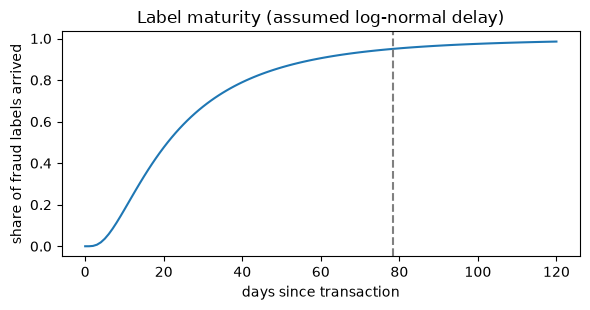

In [31]:
label_delay = dict(median_delay_days=21, lognormal_sigma=0.8, true_fraud_rate=0.001)
show_assumptions("chargeback label delay", label_delay)
delay_dist = stats.lognorm(s=label_delay["lognormal_sigma"], scale=label_delay["median_delay_days"])
ages = np.array([1, 7, 14, 30, 60, 90])
matured = delay_dist.cdf(ages)
print(pd.DataFrame({"transaction age (days)": ages, "labels arrived": [f"{m:.1%}" for m in matured],
                    "observed fraud rate": [f"{label_delay['true_fraud_rate'] * m:.4%}" for m in matured]}).to_string(index=False))
safe_age = delay_dist.ppf(0.95)
print(f"→ wait ≈ {safe_age:.0f} days for 95% of labels, or model the delay explicitly")

days_axis = np.arange(0, 121)
fig, ax = plt.subplots(figsize=(6, 3.2))
ax.plot(days_axis, delay_dist.cdf(days_axis))
ax.axvline(safe_age, ls="--", color="gray")
ax.set(xlabel="days since transaction", ylabel="share of fraud labels arrived", title="Label maturity (assumed log-normal delay)")
plt.tight_layout()
plt.show()

**Strategies:** train only on data older than the maturity window (at the cost of staleness); use a two-model setup (fast proxy labels like "customer disputed within 48 h", plus final labels); weight recent examples by label completeness; use survival-style models; and for monitoring, rely on proxy metrics until labels mature.

### ✍️ Your Turn

A fraud model has recall 0.8 and FPR 0.01, and the fraud prevalence is 0.2%. What share of flagged transactions are actually fraud? Store it in `flag_precision`.

In [32]:
flag_precision = None  # TODO: your code here
check("flag_precision", flag_precision, 0.8 * 0.002 / (0.8 * 0.002 + 0.01 * 0.998), rtol=1e-6,
      hint="precision = R·π / (R·π + FPR·(1−π))")

⏳ flag_precision: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
recall_, fpr_, prevalence_ = 0.8, 0.01, 0.002
flag_precision = recall_ * prevalence_ / (recall_ * prevalence_ + fpr_ * (1 - prevalence_))
check("flag_precision", flag_precision, 0.8 * 0.002 / (0.8 * 0.002 + 0.01 * 0.998))
```

About 14%, so roughly six false alarms per real fraud. That's why fraud systems use review queues, step-up authentication and cost-based thresholds instead of blocking every flag.
</details>

**Q32. Your fraud model is 99.9% accurate. Is it good?**

<details><summary>Show answer</summary>

- **30-second answer:** Unknown. If fraud prevalence is 0.1%, predicting "not fraud" for everything is also 99.9% accurate. Report recall, precision (or PR-AUC), recall at a fixed false-positive rate, and **dollar-weighted** metrics such as fraud losses caught vs good customers declined.
- **Go deeper:** Pick the threshold from costs: decline when P(fraud) × fraud loss > P(legit) × cost of a false decline. Evaluate on a future time window, and separately for high-value transactions.
- **❌ Common wrong answer:** "Yes: anything above 99% accuracy is excellent."

</details>

**Q33. Should you oversample, undersample, or reweight for a 1:1000 imbalanced problem?**

<details><summary>Show answer</summary>

- **30-second answer:** Often **none is needed for ranking quality**: GBDT and logistic regression handle imbalance, and you choose the threshold afterwards. Downsample negatives when data volume is the problem, and then **re-calibrate** with q = p / (p + (1−p)/w). Class weights help when the loss would otherwise ignore the minority class. SMOTE-style synthetic oversampling rarely helps large tabular production systems and can hurt calibration.
- **Go deeper:** What matters is evaluating with the right metrics at the real prevalence, and calibrating if probabilities are consumed downstream. Validate any resampling choice on a time-based holdout with the true class ratio.
- **❌ Common wrong answer:** "Always balance the classes to 50/50 before training."

</details>

**Q34. Labels arrive 30–90 days late. How do you train and evaluate the model?**

<details><summary>Show answer</summary>

- **30-second answer:** Train on a window whose labels have matured (for example, transactions older than the 95th-percentile delay), and don't treat unlabelled recent rows as negatives. Add fast proxy labels (disputes, manual review outcomes, user reports) for fresher signal. Evaluate on the most recent **matured** window, and monitor recent traffic with label-free signals (score distribution, drift, review hit rate).
- **Go deeper:** Techniques include delayed-feedback models that estimate the probability a label will still arrive, importance weighting by label completeness, and periodic backfilled re-evaluation of past predictions once labels mature.
- **❌ Common wrong answer:** "Treat everything without a chargeback yet as legitimate and train on yesterday's data."

</details>

## 15. Building Block: Fairness and Privacy 🟡

### Fairness: measure per group, then choose a definition

A model can look accurate overall and still make systematically different errors for different groups. Common definitions, which **conflict** when base rates differ between groups:

| Definition | Requires equal … across groups | Typical use |
|---|---|---|
| **Demographic parity** | Positive prediction rate | Exposure or opportunity allocation |
| **Equal opportunity** | True-positive rate (recall) | Qualified people should be approved equally often |
| **Equalized odds** | True-positive **and** false-positive rates | Error rates matter for both outcomes |
| **Calibration within groups** | P(positive \| score) | Scores are consumed as probabilities |

The **synthetic** example below has two groups whose score distributions differ slightly (for example because a feature is less informative for group B). One shared threshold then produces different error rates:

In [33]:
fair_rng = np.random.default_rng(3)
n_per_group = 50_000
group_rows = []
for group, base_rate, separation in (("A", 0.30, 1.6), ("B", 0.15, 1.0)):     # assumed: signal is weaker for group B
    label = fair_rng.random(n_per_group) < base_rate
    score = fair_rng.normal(loc=np.where(label, separation, 0.0), scale=1.0)
    group_rows.append(pd.DataFrame({"group": group, "label": label, "score": score}))
fair_df = pd.concat(group_rows, ignore_index=True)
threshold = 1.0
fair_df["approved"] = fair_df["score"] > threshold
summary = fair_df.groupby("group").apply(lambda g: pd.Series({
    "base rate": g["label"].mean(),
    "approval rate": g["approved"].mean(),
    "TPR (recall)": g.loc[g["label"], "approved"].mean(),
    "FPR": g.loc[~g["label"], "approved"].mean(),
    "AUC": roc_auc_score(g["label"], g["score"]),
}), include_groups=False)
print(summary.round(3).to_string())
tpr_gap = summary.loc["A", "TPR (recall)"] - summary.loc["B", "TPR (recall)"]
print(f"\n→ equal-opportunity gap (TPR A − TPR B) at one shared threshold: {tpr_gap:+.3f}")

       base rate  approval rate  TPR (recall)    FPR    AUC
group                                                      
A          0.302          0.331         0.729  0.159  0.871
B          0.147          0.208         0.502  0.157  0.757

→ equal-opportunity gap (TPR A − TPR B) at one shared threshold: +0.226


Mitigation options: better features or data for the under-served group (usually the best fix), per-group thresholds (legal constraints vary by domain), fairness-constrained training, and re-ranking for exposure fairness in recommendations. Always report **slice metrics** in offline evaluation and in A/B tests.

### Privacy

- **Data minimization and retention:** collect only what the model needs; expire raw logs.
- **Consent and purpose limitation:** use data only for purposes users agreed to; respect opt-outs in training data as well as serving.
- **PII handling:** pseudonymous IDs, access control, encryption, no raw PII in feature stores or logs.
- **Deletion requests:** remove the user's data from training sets and features; retrain on schedule. Models can memorize, so deletion must be part of the retraining process.
- **Stronger techniques:** differential privacy (bounded influence of any individual), federated learning (training on-device), aggregation thresholds for analytics.

**Q35. Your loan-approval model has equal accuracy for two groups, but very different false-negative rates. What do you do?**

<details><summary>Show answer</summary>

- **30-second answer:** Equal accuracy can hide unequal errors. Qualified applicants in one group are wrongly rejected more often, which violates **equal opportunity**. Investigate why (missing or less informative features, label bias, under-representation), improve data and features first, then consider constrained training or threshold adjustments within legal rules, and monitor per-group metrics continuously.
- **Go deeper:** Explain the impossibility result. When base rates differ, you generally can't have calibration within groups and equal false-positive and false-negative rates at the same time. So the choice of fairness definition is a product, legal and ethical decision, not only a technical one. Involve stakeholders and document it.
- **❌ Common wrong answer:** "Remove the sensitive attribute from the features, and the model is fair." Proxies (zip code, school) still carry the information, and you lose the ability to measure the gap.

</details>

**Q36. A user asks for their data to be deleted. What does that mean for your ML system?**

<details><summary>Show answer</summary>

- **30-second answer:** Delete their raw events and derived features from the data warehouse, the feature stores (offline and online), caches and training snapshots within the required time frame. Ensure future training runs exclude them, and retrain or refresh models on a schedule so their influence disappears. Precomputed per-user artifacts (embeddings, recommendation lists) must be deleted immediately.
- **Go deeper:** Design for deletion: keep lineage from raw data to datasets to models, store training data in formats where rows can be removed, and avoid copying user data into many ad-hoc places. Machine unlearning research exists, but scheduled retraining is the practical approach for most teams.
- **❌ Common wrong answer:** "The model is aggregated statistics, so nothing needs to change."

</details>

## 16. Case Study: Recommendation Feed 🔴

> **Prompt:** "Design the home feed for a short-video app."

### Clarify (the answers are our stated assumptions)

- **Surface:** a vertical feed; the user swipes, and each view is an implicit signal. There are no ads in scope.
- **Goal:** long-term engagement and retention, not just clicks.
- **Scale:** tens of millions of daily users and hundreds of millions of videos. See the capacity cell for the exact assumptions.
- **Latency:** under ~200 ms p99 for a page of 10 videos. **Freshness:** a new upload should be recommendable within minutes, and session behaviour should affect the next page.

### Metrics

| Layer | Metric |
|---|---|
| Business | 7-day and 28-day retention, daily active users |
| Online (A/B) | Watch time per user, sessions per user, completion rate, shares, follows |
| Offline | Retrieval recall@k; ranking NDCG@k and per-task log loss (watch, like, share, hide) |
| Guardrails | p99 latency, hides and reports, creator exposure concentration, share of fresh videos, diversity per session |

### Architecture

```mermaid
flowchart LR
    APP["App"] --> FEED["Feed service"]
    subgraph retrieval["Candidate generation, about 1,000 total"]
        R1["Two-tower ANN"]
        R2["Followed creators"]
        R3["Trending in region"]
        R4["Fresh uploads, exploration"]
    end
    FEED --> R1
    FEED --> R2
    FEED --> R3
    FEED --> R4
    R1 --> PRE["Pre-ranker, light model"]
    R2 --> PRE
    R3 --> PRE
    R4 --> PRE
    PRE --> RANK["Multi-task ranker: watch, like, share, hide"]
    FS[("Online feature store")] --> RANK
    RANK --> RERANK["Re-ranking: diversity, dedup, policy filters"]
    RERANK --> FEED
    FEED --> LOGS["Impression and engagement logs"]
    LOGS --> TRAIN["Daily training + streaming embedding updates"]
    TRAIN --> RANK
    TRAIN --> IDX[("ANN index of item embeddings")]
    IDX --> R1
```

### Capacity estimate

In [34]:
feed = dict(
    daily_active_users=50_000_000,
    feed_requests_per_user_per_day=12,
    peak_to_average_ratio=2.5,
    corpus_items=200_000_000,
    embedding_dim=128,
    pq_code_bytes=64,
    candidates_per_request=1_000,
    ranker_cpu_ms_per_request=40,          # scoring 1,000 candidates — measure your own model
    target_cpu_utilization=0.5,            # headroom for spikes and failover
    items_shown_per_request=10,
    bytes_per_impression_log_row=250,
    new_uploads_per_day=5_000_000,
)
show_assumptions("short-video home feed", feed)

feed_requests_day = feed["daily_active_users"] * feed["feed_requests_per_user_per_day"]
feed_peak_qps = feed_requests_day / SECONDS_PER_DAY * feed["peak_to_average_ratio"]
ranking_cores = feed_peak_qps * feed["ranker_cpu_ms_per_request"] / 1000 / feed["target_cpu_utilization"]
feed_impressions = feed_requests_day * feed["items_shown_per_request"]
print(f"feed requests/day        : {human(feed_requests_day)} | peak QPS {feed_peak_qps:,.0f}")
print(f"candidate scores/s (peak): {human(feed_peak_qps * feed['candidates_per_request'])}")
print(f"CPU cores for ranking    : {ranking_cores:,.0f} at {feed['target_cpu_utilization']:.0%} utilization")
print(f"ANN index, flat float32  : {gib(feed['corpus_items'] * feed['embedding_dim'] * 4)} | PQ {feed['pq_code_bytes']} bytes: "
      f"{gib(feed['corpus_items'] * feed['pq_code_bytes'])}")
print(f"impressions/day          : {human(feed_impressions)} → logs {gib(feed_impressions * feed['bytes_per_impression_log_row'])}/day")
print(f"new uploads to embed     : {feed['new_uploads_per_day'] / SECONDS_PER_DAY:,.0f} per second on average")

ASSUMPTIONS — short-video home feed (illustrative: replace with the numbers your interviewer gives)
  daily_active_users             = 50,000,000
  feed_requests_per_user_per_day = 12
  peak_to_average_ratio          = 2.5
  corpus_items                   = 200,000,000
  embedding_dim                  = 128
  pq_code_bytes                  = 64
  candidates_per_request         = 1,000
  ranker_cpu_ms_per_request      = 40
  target_cpu_utilization         = 0.5
  items_shown_per_request        = 10
  bytes_per_impression_log_row   = 250
  new_uploads_per_day            = 5,000,000

feed requests/day        : 600.0M | peak QPS 17,361
candidate scores/s (peak): 17.4M
CPU cores for ranking    : 1,389 at 50% utilization
ANN index, flat float32  : 95.4 GiB | PQ 64 bytes: 11.9 GiB
impressions/day          : 6.0B → logs 1,397.0 GiB/day
new uploads to embed     : 58 per second on average


**What the numbers tell us:** under these assumptions, ranking alone needs over a thousand CPU cores at peak, so a pre-ranker that cuts 1,000 candidates to a few hundred saves real money. The flat index doesn't fit on one machine, so use PQ or sharding. Impression logs are the training data, so plan storage and negative downsampling.

### Design walk-through

- **Data & labels:** impressions joined with engagement (watch seconds, completion, like, share, follow, hide, report). Negatives are impressions without engagement. Labels arrive within seconds to minutes, except retention.
- **Features:** user (long-term interest embeddings, recent session topics, device, locale), item (content embeddings from video/audio/text, creator stats, age, quality score), cross (user–creator affinity, topic match), context (time, network). All point-in-time correct, with **served features logged**.
- **Models:** retrieval uses a two-tower model with in-batch negatives and sampling-bias correction, plus rule-based sources. Ranking uses a multi-task deep model (shared bottom + task heads). The final score is a weighted combination, e.g. `w1·P(complete) + w2·E[watch time] + w3·P(share) − w4·P(hide)`, with weights tuned by A/B tests on long-term metrics. The baseline is GBDT on hand-made features with popularity candidates.
- **Serving:** online ranking per page. Precomputed item embeddings; user embedding computed per request from recent history. Fallbacks: cached last page → regional trending.
- **Evaluation:** offline on the next day's logs (recall@k per source, NDCG and log loss per task, slices for new users and new creators). Online: an A/B test randomized by user for ≥2 weeks, plus a long-term holdout for retention.
- **Monitoring:** engagement per cohort, score distributions, embedding freshness, index recall, creator exposure concentration.

| Trade-off | Option A | Option B | Our choice |
|---|---|---|---|
| Objective | Maximize watch time | Weighted multi-objective with negative signals | B: watch time alone rewards bingeable low-quality content |
| Freshness | Daily retrain | Daily retrain + streaming embedding/feature updates | B: short videos and trends change within hours |
| Candidates | One embedding source | Several sources with quotas | Several, for coverage and exploration |
| Exploration | Pure exploitation | Fixed small exploration budget | Budget: needed for cold start and to avoid feedback loops |

**Q37. Users complain the feed is repetitive ("filter bubble"). How do you address it?**

<details><summary>Show answer</summary>

- **30-second answer:** Measure it first: topic entropy per session, the share of recommendations from the user's top topic, and repeat-creator rate. Then (1) add diversity in re-ranking (for example MMR, or per-topic and per-creator caps), (2) add exploration candidates from adjacent interests, (3) include negative feedback (skips, hides) and satiation features ("already watched 5 cooking videos today"), and (4) A/B test on long-term retention, not just same-session watch time.
- **Go deeper:** Diversity often lowers short-term engagement slightly and raises long-term retention, so the A/B test needs long-term metrics or a holdout. Learned approaches include determinantal point processes or slate-level models that score the whole page.
- **❌ Common wrong answer:** "Randomly shuffle the results." That hurts relevance without targeting the repetition.

</details>

**Q38. How would you combine several predicted engagement probabilities into one ranking score?**

<details><summary>Show answer</summary>

- **30-second answer:** Use a weighted sum (or product) of calibrated task predictions, with negative weights for negative actions, e.g. `score = a·P(watch) + b·E[watch_time] + c·P(like) − d·P(hide)`. Start with weights that reflect business value, then tune them with online experiments, because offline metrics can't tell you the right trade-off between objectives.
- **Go deeper:** Calibrate each head so the weights mean something. Consider per-surface weights, and use Bayesian optimization or multi-armed bandits over weight vectors to tune efficiently. Guard against one task dominating as its scale drifts.
- **❌ Common wrong answer:** "Train one model on clicks only; the other signals are noise."

</details>

**Q39. The feed must reflect what a user did in the last minute. What changes?**

<details><summary>Show answer</summary>

- **30-second answer:** Add **session features** (the last N watched items, their embeddings and the watch-completion pattern) computed at request time from a recent-events store, and compute the user embedding per request from those events instead of a nightly batch. The ranker (or a sequence model over recent items) uses them directly.
- **Go deeper:** Infrastructure: client → event stream → per-user recent-events store with low latency, keeping training consistent via logged features. Test the value first by training with the session features delayed, to see how much freshness actually buys.
- **❌ Common wrong answer:** "Retrain the whole model every minute."

</details>

## 17. Case Study: Real-Time Payment Fraud Detection 🔴

> **Prompt:** "Design a system that detects fraudulent card payments for an online payments company."

### Clarify

- **Decision:** approve, decline, or send to **step-up** (for example 3-D Secure or one-time code) or manual review, **before** authorization completes.
- **Latency:** the decision must fit inside the payment flow: assume **p99 ≤ 100 ms** for scoring.
- **Labels:** chargebacks (weeks later), manual review outcomes (hours), customer disputes.
- **Costs:** missed fraud costs the transaction amount plus fees; a false decline costs lost margin and customer trust.

### Metrics

| Layer | Metric |
|---|---|
| Business | Fraud loss (basis points of volume), false-decline rate, approval rate, customer churn after declines |
| Online | Chargeback rate (delayed), decline rate, step-up completion rate, review hit rate |
| Offline | PR-AUC, recall at fixed FPR, **dollar-weighted recall**, expected cost at the chosen threshold |
| Guardrails | p99 latency, review queue size, approval rate by country and merchant segment |

### Architecture

```mermaid
flowchart LR
    PAY["Checkout / card network"] --> API["Risk scoring API, p99 under 100 ms"]
    API --> RULES["Rules: blocklists, hard limits"]
    API --> FEAT["Feature assembly"]
    ONLINE[("Online store: velocity counts, card, device, merchant history")] --> FEAT
    FEAT --> MODEL["GBDT risk model"]
    RULES --> DECIDE{"Decision"}
    MODEL --> DECIDE
    DECIDE -->|"low risk"| APPROVE["Approve"]
    DECIDE -->|"medium risk"| STEPUP["Step-up auth or manual review"]
    DECIDE -->|"high risk"| DECLINE["Decline"]
    API --> STREAM["Stream processor"]
    STREAM --> ONLINE
    STEPUP --> FAST["Review outcomes: fast labels"]
    CHARGE["Chargebacks, weeks later"] --> LABELS[("Label store")]
    FAST --> LABELS
    LABELS --> TRAIN["Retrain on matured labels"]
    TRAIN --> MODEL
```

### Capacity and expected-cost estimate

If a false decline costs $C_{FP}$ and a missed fraud costs $C_{FN}$, declining is worth it when $p\,C_{FN} > (1-p)\,C_{FP}$, i.e. when **$p > C_{FP}/(C_{FP}+C_{FN})$**. The cost-optimal threshold therefore comes from money, not from the F1 score. (This assumes a calibrated $p$; with per-transaction amounts, use the amount as $C_{FN}$.)

In [35]:
fraud = dict(
    transactions_per_day=30_000_000,
    peak_to_average_ratio=4.0,
    fraud_rate=0.001,
    avg_fraud_amount_usd=120.0,             # cost of a missed fraud (C_FN)
    false_decline_cost_usd=8.0,             # lost margin + churn risk (C_FP) — a business estimate
    recall_at_threshold=0.70,               # from the offline PR curve at the chosen threshold
    fpr_at_threshold=0.002,
    share_sent_to_manual_review=0.002,
    seconds_per_manual_review=120,
    reviewer_productive_hours_per_day=6,
)
show_assumptions("card-not-present payments", fraud)

tx = fraud["transactions_per_day"]
fraud_peak_tps = tx / SECONDS_PER_DAY * fraud["peak_to_average_ratio"]
optimal_threshold = fraud["false_decline_cost_usd"] / (fraud["false_decline_cost_usd"] + fraud["avg_fraud_amount_usd"])
frauds = tx * fraud["fraud_rate"]
caught = frauds * fraud["recall_at_threshold"]
false_declines = tx * (1 - fraud["fraud_rate"]) * fraud["fpr_at_threshold"]
reviewers = tx * fraud["share_sent_to_manual_review"] * fraud["seconds_per_manual_review"] / (fraud["reviewer_productive_hours_per_day"] * 3600)

print(f"peak transactions/s        : {fraud_peak_tps:,.0f}")
print(f"cost-optimal decline threshold: P(fraud) > {optimal_threshold:.3f}")
print(f"frauds/day                 : {frauds:,.0f} → caught {caught:,.0f} (${caught * fraud['avg_fraud_amount_usd']:,.0f}), "
      f"missed ${(frauds - caught) * fraud['avg_fraud_amount_usd']:,.0f}")
print(f"false declines/day         : {false_declines:,.0f} (cost ${false_declines * fraud['false_decline_cost_usd']:,.0f}) | "
      f"precision of declines {caught / (caught + false_declines):.1%}")
print(f"manual reviewers needed    : {math.ceil(reviewers):,}")

ASSUMPTIONS — card-not-present payments (illustrative: replace with the numbers your interviewer gives)
  transactions_per_day              = 30,000,000
  peak_to_average_ratio             = 4.0
  fraud_rate                        = 0.001
  avg_fraud_amount_usd              = 120.0
  false_decline_cost_usd            = 8.0
  recall_at_threshold               = 0.7
  fpr_at_threshold                  = 0.002
  share_sent_to_manual_review       = 0.002
  seconds_per_manual_review         = 120
  reviewer_productive_hours_per_day = 6

peak transactions/s        : 1,389
cost-optimal decline threshold: P(fraud) > 0.062
frauds/day                 : 30,000 → caught 21,000 ($2,520,000), missed $1,080,000
false declines/day         : 59,940 (cost $479,520) | precision of declines 25.9%
manual reviewers needed    : 334


### Design walk-through

- **Features:** velocity (transactions per card, device, IP and email over 1 min, 1 h and 24 h), amount vs the card's typical amount, merchant risk, device fingerprint, geo mismatch (IP country vs card country), account age, and **graph features** (how many cards share this device or address). Most are streaming features with point-in-time training via the event log.
- **Model:** GBDT for tabular features: fast, strong and explainable enough for reason codes. Rules stay for known patterns and regulatory blocks. A graph model or anomaly detector can help find new fraud rings.
- **Serving:** synchronous scoring with strict timeouts. If the model is unavailable, fall back to rules with conservative limits (fail-open vs fail-closed is a business decision per merchant).
- **Labels & training:** matured chargebacks + review outcomes. Train on data older than the label maturity window. Transactions that were **declined have no outcome**, so reserve a tiny randomized approval slice (within risk limits) or use reject-inference techniques to avoid a blind spot.
- **Adversaries:** fraudsters probe and adapt. Monitor new-pattern signals, retrain often, and keep a fast rule path for emergencies.

| Trade-off | Choice and why |
|---|---|
| Rules vs ML | Both: rules for hard constraints and instant response to new attacks; ML for generalization |
| Threshold | Cost-based and per segment (amount, merchant category), not one global F1-optimal cut |
| Latency vs features | Drop features whose p99 lookup breaks the budget, or precompute them |
| Explainability | Keep reason codes (top feature contributions) for reviewers and regulators |

**Q40. You only observe outcomes for approved transactions. Why is that a problem, and what can you do?**

<details><summary>Show answer</summary>

- **30-second answer:** It's **selection bias**. The model never learns what would have happened to the transactions it declined, so its future training data is shaped by past decisions (a feedback loop), and borderline good customers stay declined forever. Mitigations: approve a small random sample of would-be declines under strict loss limits, use step-up authentication outcomes as labels, and apply reject-inference or counterfactual evaluation.
- **Go deeper:** Evaluate new models with off-policy methods using the logged decision probabilities, which requires logging the propensity of each decision. Monitor approval rates per segment for unexplained drops.
- **❌ Common wrong answer:** "Declined transactions are fraud, so label them as positives."

</details>

**Q41. Fraudsters change tactics weekly. How does your design keep up?**

<details><summary>Show answer</summary>

- **30-second answer:** A **fast path** of rules and blocklists that analysts can deploy in minutes. **Frequent retraining** with fast proxy labels (review outcomes, disputes). Features that generalize (velocity, graph links) rather than memorized patterns. And monitoring that alerts on new clusters or spikes in declines, disputes or specific merchant categories.
- **Go deeper:** Add anomaly detection or unsupervised clustering to surface new patterns for analysts. Run a challenger model in shadow mode, and keep feature and model rollout independent so you can respond quickly without risky full redeploys.
- **❌ Common wrong answer:** "Retrain the model quarterly on all historical data."

</details>

**Q42. How do you choose the decision threshold for a fraud model?**

<details><summary>Show answer</summary>

- **30-second answer:** From **expected cost**: decline when P(fraud) × loss if fraud > P(legit) × cost of a false decline, which gives the threshold C_FP / (C_FP + C_FN). This needs calibrated probabilities. In practice use three bands (approve / step-up or review / decline), and pick band boundaries from review capacity and cost curves on a recent validation window.
- **Go deeper:** Make thresholds amount- and segment-aware (a $5 digital purchase vs a $2,000 laptop). Revisit them when fraud rates or costs change, and check them per country for fairness and business impact.
- **❌ Common wrong answer:** "Use 0.5" or "maximize F1."

</details>

## 18. Case Study: Search Ranking 🔴

> **Prompt:** "Design product search ranking for a large e-commerce site."

### Clarify

- **Users type free-text queries**, and results can be filtered (price, brand).
- **Goal:** purchases and customer satisfaction; relevance must come first.
- **Latency:** about 150 ms p99 for the first results page.
- **Data:** query logs with clicks, add-to-cart and purchases; product catalogue text, images and attributes; the ability to pay for human relevance judgments.

### Metrics

| Layer | Metric |
|---|---|
| Business | Search conversion rate, revenue per search, customer return rate |
| Online | Click-through on top results, add-to-cart rate, zero-result rate, query reformulation rate, time to first click |
| Offline | NDCG@10 on human judgments and on debiased click labels, MRR, recall@1000 of retrieval |
| Guardrails | p99 latency, zero-result rate, sponsored-slot quality, seller diversity |

### Architecture

```mermaid
flowchart LR
    QUERY["Query"] --> QU["Query understanding: spelling, language, category intent"]
    QU --> LEX["Lexical retrieval: BM25 inverted index"]
    QU --> SEM["Semantic retrieval: embedding ANN"]
    LEX --> MERGE["Merge and dedupe, about 1,000"]
    SEM --> MERGE
    MERGE --> LTR["Learning-to-rank model"]
    FEATS[("Query, product and user features")] --> LTR
    LTR --> BIZ["Business rules: availability, sponsored slots, diversity"]
    BIZ --> SERP["Results page"]
    SERP --> LOGS["Clicks, add-to-cart, purchases"]
    LOGS --> LABELS["Debiased click labels + human relevance judgments"]
    LABELS --> LTR
```

### Capacity estimate

In [36]:
search = dict(
    searches_per_day=40_000_000,
    peak_to_average_ratio=3.0,
    catalog_products=80_000_000,
    embedding_dim=384,
    ltr_cpu_ms_per_request=15,               # GBDT on ~1,000 candidates — measure
    target_cpu_utilization=0.5,
    judged_queries=5_000,
    results_judged_per_query=20,
    judgments_per_result=3,                  # several raters per item to measure agreement
    usd_per_judgment=0.10,                   # vendor quote placeholder — ask your vendor
)
show_assumptions("e-commerce product search", search)

search_peak_qps = search["searches_per_day"] / SECONDS_PER_DAY * search["peak_to_average_ratio"]
emb_float32 = search["catalog_products"] * search["embedding_dim"] * 4
emb_int8 = search["catalog_products"] * search["embedding_dim"] * 1
judgments = search["judged_queries"] * search["results_judged_per_query"] * search["judgments_per_result"]
print(f"peak QPS                    : {search_peak_qps:,.0f}")
print(f"embeddings float32 / int8   : {gib(emb_float32)} / {gib(emb_int8)}")
print(f"CPU cores for LTR at peak   : {search_peak_qps * search['ltr_cpu_ms_per_request'] / 1000 / search['target_cpu_utilization']:,.0f}")
print(f"human judgments             : {judgments:,} → ${judgments * search['usd_per_judgment']:,.0f} per evaluation set")

ASSUMPTIONS — e-commerce product search (illustrative: replace with the numbers your interviewer gives)
  searches_per_day         = 40,000,000
  peak_to_average_ratio    = 3.0
  catalog_products         = 80,000,000
  embedding_dim            = 384
  ltr_cpu_ms_per_request   = 15
  target_cpu_utilization   = 0.5
  judged_queries           = 5,000
  results_judged_per_query = 20
  judgments_per_result     = 3
  usd_per_judgment         = 0.1

peak QPS                    : 1,389
embeddings float32 / int8   : 114.4 GiB / 28.6 GiB
CPU cores for LTR at peak   : 42
human judgments             : 300,000 → $30,000 per evaluation set


### Design walk-through

- **Retrieval:** hybrid. BM25 handles exact matches (model numbers, brands) and embeddings handle meaning ("running shoes" ↔ "trainers"). Merge with reciprocal rank fusion or a learned merger. See [Embeddings and Semantic Search §9](../05_NLP/02_Embeddings_and_Semantic_Search.ipynb).
- **Features:** query–product text match (BM25 score, embedding similarity), product quality (rating, return rate, sales velocity), price and availability, query category match, personalization (brand affinity), and context (device, location).
- **Model:** a LambdaMART-style GBDT ranker (optimizes NDCG directly via pairwise gradients) as the strong baseline. A cross-encoder re-ranker for the top ~50 if the latency budget allows.
- **Labels:** human judgments (precise, expensive, used for evaluation and training), and click/purchase logs (abundant but **position-biased**; use IPS or randomized interleaving to debias; see Section 13).
- **Evaluation:** NDCG@10 on the judged set + debiased click metrics offline; **interleaving** for fast online comparisons, then an A/B test on conversion.

| Trade-off | Choice and why |
|---|---|
| Lexical vs semantic | Hybrid: each fails where the other succeeds |
| Personalization | Light: relevance first, personal signals as tie-breakers |
| Human vs click labels | Both: humans for a trusted evaluation set, clicks for scale |
| Cross-encoder re-ranking | Only for top results within the latency budget |

**Q43. Why is NDCG a better offline metric than accuracy for search, and what are its limits?**

<details><summary>Show answer</summary>

- **30-second answer:** Search quality depends on **order**, and users mostly look at the top. NDCG rewards putting highly relevant items first by discounting gains logarithmically by position, supports graded relevance (perfect / good / bad), and is normalized per query so queries are comparable.
- **Go deeper:** Limits: it depends on judged items (unjudged results count as irrelevant), the gain and discount choices are arbitrary, and it doesn't capture diversity, price or availability. Complement it with MRR for navigational queries, zero-result rate, and online metrics.
- **❌ Common wrong answer:** "Use accuracy of predicting clicks."

</details>

**Q44. Click logs say result #1 gets 10× the clicks of result #5. Can you train the ranker on raw clicks?**

<details><summary>Show answer</summary>

- **30-second answer:** Not directly: much of that difference is **position bias**. Training on raw clicks teaches the model to copy the current ranking. Estimate examination propensities per position (for example, from small result-swap experiments) and use inverse propensity weighting, or add position as a training-only feature, and validate on human judgments.
- **Go deeper:** Also consider **trust bias** (users trust the top result) and **presentation bias** (images, badges). Purchases and add-to-cart are less noisy than clicks but rarer. Weight them in a graded label.
- **❌ Common wrong answer:** "Clicks are the ground truth of relevance."

</details>

**Q45. Many queries return zero or poor results. How would you improve recall for them?**

<details><summary>Show answer</summary>

- **30-second answer:** Analyze zero-result queries by type: spelling errors → spelling correction; synonyms or vocabulary mismatch → semantic retrieval and query expansion; too-specific filters → relax constraints with a clear UI message; out-of-catalogue items → show related categories. Measure the zero-result rate and reformulation rate per fix.
- **Go deeper:** Learn query rewrites from logs (query A reformulated to B followed by a purchase), use a small LLM or seq2seq model offline to generate rewrites for tail queries, and cache them. Evaluate rewrites carefully, because they can change intent.
- **❌ Common wrong answer:** "Lower the relevance threshold so something always shows."

</details>

## 19. Case Study: Ads Click-Through-Rate Prediction 🔴

> **Prompt:** "Design the click-through-rate (CTR) prediction system for an ads platform."

### Clarify

- Ads are chosen by an **auction**. The expected value of showing an ad is roughly `bid × pCTR` (for cost-per-click bids), so **predicted probabilities are used as numbers, not just for ordering**. Calibration is critical.
- Huge, sparse, high-cardinality features (user, ad, advertiser, publisher, context), and very fresh data matters (new campaigns constantly).
- Latency is tight: the whole ad decision fits into a page load.

### Metrics

| Layer | Metric |
|---|---|
| Business | Revenue, advertiser return on ad spend, long-term user engagement |
| Online | Revenue per mille (RPM), CTR, conversion rate, advertiser retention |
| Offline | **Log loss / normalized entropy (NE)**, calibration ratio (Σ predicted ÷ Σ actual clicks), AUC |
| Guardrails | Ad load and user complaints, latency, budget pacing accuracy |

**Normalized entropy** (He et al., 2014) is the average log loss divided by the entropy of the background CTR. Below 1.0 means better than always predicting the average rate.

### Architecture

```mermaid
flowchart LR
    REQ["Ad request: user, page, context"] --> ELIG["Targeting and eligibility filter"]
    ELIG --> LIGHT["Light model scores thousands of ads"]
    LIGHT --> HEAVY["Heavy CTR model scores the top 100"]
    FS[("Features: user, ad, advertiser, context")] --> HEAVY
    HEAVY --> AUCTION["Auction: rank by bid x pCTR plus quality"]
    PACING["Budget pacing"] --> AUCTION
    AUCTION --> SHOW["Show ad"]
    SHOW --> LOGS["Impressions, clicks, delayed conversions"]
    LOGS --> JOIN["Join labels within attribution window"]
    JOIN --> TRAIN["Frequent incremental training + recalibration"]
    TRAIN --> HEAVY
```

### Capacity estimate

In [37]:
ads = dict(
    ad_requests_per_day=2_000_000_000,
    peak_to_average_ratio=2.0,
    ads_shown_per_request=3,
    average_ctr=0.01,
    heavy_model_ads_per_request=100,
    heavy_scores_per_second_per_gpu=200_000,     # measure: depends on model size and batching
    target_gpu_utilization=0.6,
    sparse_features=40,
    hash_buckets_per_feature=5_000_000,
    embedding_dim=16,
    negative_keep_rate=0.05,                     # keep 5% of non-clicks for training
)
show_assumptions("ads CTR prediction", ads)

ads_peak_qps = ads["ad_requests_per_day"] / SECONDS_PER_DAY * ads["peak_to_average_ratio"]
impressions = ads["ad_requests_per_day"] * ads["ads_shown_per_request"]
clicks_day = impressions * ads["average_ctr"]
training_rows = clicks_day + (impressions - clicks_day) * ads["negative_keep_rate"]
embedding_bytes = ads["sparse_features"] * ads["hash_buckets_per_feature"] * ads["embedding_dim"] * 4
gpus = ads_peak_qps * ads["heavy_model_ads_per_request"] / ads["heavy_scores_per_second_per_gpu"] / ads["target_gpu_utilization"]
print(f"peak ad requests/s     : {ads_peak_qps:,.0f}")
print(f"impressions/day        : {human(impressions)} | clicks/day {human(clicks_day)}")
print(f"training rows/day      : {human(training_rows)} after keeping {ads['negative_keep_rate']:.0%} of negatives (re-calibrate!)")
print(f"embedding tables       : {gib(embedding_bytes)} (float32)")
print(f"GPUs for heavy scoring : {math.ceil(gpus):,}")

ASSUMPTIONS — ads CTR prediction (illustrative: replace with the numbers your interviewer gives)
  ad_requests_per_day             = 2,000,000,000
  peak_to_average_ratio           = 2.0
  ads_shown_per_request           = 3
  average_ctr                     = 0.01
  heavy_model_ads_per_request     = 100
  heavy_scores_per_second_per_gpu = 200,000
  target_gpu_utilization          = 0.6
  sparse_features                 = 40
  hash_buckets_per_feature        = 5,000,000
  embedding_dim                   = 16
  negative_keep_rate              = 0.05

peak ad requests/s     : 46,296
impressions/day        : 6.0B | clicks/day 60.0M
training rows/day      : 357.0M after keeping 5% of negatives (re-calibrate!)
embedding tables       : 11.9 GiB (float32)
GPUs for heavy scoring : 39


### Why calibration matters more than AUC here

A **synthetic** demonstration: we know every impression's true click probability. Three "models" rank impressions **identically** (so AUC is identical), but their probabilities differ.

In [38]:
cal_rng = np.random.default_rng(11)
true_ctr = cal_rng.beta(1.2, 110, 500_000)                  # assumed CTR distribution, mean ≈ 1.1%
clicked = cal_rng.random(true_ctr.size) < true_ctr


def normalized_entropy(y_true, p_pred):
    base = y_true.mean()                                     # background CTR of this evaluation set
    return log_loss(y_true, p_pred) / -(base * math.log(base) + (1 - base) * math.log(1 - base))


candidate_models = {
    "calibrated (= true pCTR)": true_ctr,
    "over-predicts 2×": np.clip(2 * true_ctr, 0, 0.999),
    "squashed toward the mean": 0.5 * true_ctr + 0.5 * true_ctr.mean(),
}
for name, pred in candidate_models.items():
    print(f"{name:26s} AUC {roc_auc_score(clicked, pred):.4f} | NE {normalized_entropy(clicked, pred):.4f} | "
          f"calibration Σpred/Σclicks {pred.sum() / clicked.sum():.2f}")

# A toy auction (made-up bids and true CTRs): cost-per-click bids, expected revenue per 1,000 impressions = bid × CTR × 1000
bids = {"advertiser X": 2.00, "advertiser Y": 1.00}
true_ad_ctr = {"advertiser X": 0.010, "advertiser Y": 0.025}
for label, overprediction_x in (("calibrated model", 1.0), ("model over-predicts X by 2×", 2.0)):
    predicted = {"advertiser X": true_ad_ctr["advertiser X"] * overprediction_x, "advertiser Y": true_ad_ctr["advertiser Y"]}
    winner = max(bids, key=lambda a: bids[a] * predicted[a])
    realized_rpm = bids[winner] * true_ad_ctr[winner] * 1000
    print(f"{label:28s} → winner {winner}, realized revenue per 1,000 impressions ${realized_rpm:.2f}")

calibrated (= true pCTR)   AUC 0.7301 | NE 0.9364 | calibration Σpred/Σclicks 0.99


over-predicts 2×           AUC 0.7301 | NE 0.9922 | calibration Σpred/Σclicks 1.98


squashed toward the mean   AUC 0.7301 | NE 0.9534 | calibration Σpred/Σclicks 0.99
calibrated model             → winner advertiser Y, realized revenue per 1,000 impressions $25.00
model over-predicts X by 2×  → winner advertiser X, realized revenue per 1,000 impressions $20.00


AUC can't tell these models apart. NE flags both miscalibrated models. The global calibration ratio only catches the over-predicting one, because squashed predictions keep the right average. Catching those needs a per-bucket reliability check (predicted vs observed CTR within score buckets). In the auction, a miscalibrated model hands the slot to the wrong advertiser and loses revenue. That's why ads teams track log loss/NE and calibration, retrain frequently, and add a **calibration layer** (for example isotonic regression or Platt scaling on recent data) after the model.

### Design walk-through

- **Features & model:** hashed sparse IDs → embeddings, feature crosses (DCN/DLRM-style deep models, or the classic GBDT-leaf + logistic regression), dense counters (historical CTR of ad and user segment, point-in-time), context.
- **Freshness:** new ads appear constantly and CTR decays, so use incremental or online training (hourly or faster) and exploration for new ads (a confidence bonus or reserved traffic).
- **Labels:** click within a window of the impression; conversions arrive later (a delayed-feedback problem).
- **Serving:** light model → heavy model → auction, with strict timeouts; cache user embeddings per session.

**Q46. Why do ads systems care so much about calibration and log loss rather than AUC?**

<details><summary>Show answer</summary>

- **30-second answer:** The auction multiplies bids by pCTR, and advertisers are charged based on those values, so the **absolute** probability decides who wins and how much everyone pays. AUC only measures ordering and is unchanged if all predictions are doubled. Log loss (or normalized entropy) and calibration ratios catch that error.
- **Go deeper:** Calibration can differ by segment (new ads, small publishers), so check calibration per slice. Negative downsampling requires the q = p / (p + (1−p)/w) correction. Many teams add a final recalibration step trained on the freshest data.
- **❌ Common wrong answer:** "AUC is the standard classification metric, so optimize it."

</details>

**Q47. How do you handle conversions that happen days after the click?**

<details><summary>Show answer</summary>

- **30-second answer:** Define an attribution window (for example 7 days) and train the conversion model on examples whose windows have closed, **or** use a delayed-feedback model that treats "no conversion yet" as uncertain rather than negative, and correct for the probability that the conversion will still arrive. Keep the fast click model separate from the slower conversion model.
- **Go deeper:** Naively labelling fresh impressions as negatives biases the model downward for recent campaigns, which hurts new advertisers the most. Importance weighting or re-labelling when late conversions arrive (with duplicate positive examples) are common approaches.
- **❌ Common wrong answer:** "Label every impression without a conversion so far as negative and train hourly."

</details>

**Q48. A new advertiser launches a campaign. The model predicts low CTR because it has no history, so the ad never wins. What do you do?**

<details><summary>Show answer</summary>

- **30-second answer:** Use **features that generalize** (ad creative embeddings, category, advertiser vertical, landing-page content) so the prior isn't just "unknown = low", and add **exploration**: an uncertainty bonus (UCB or Thompson sampling) or a small reserved share of impressions for new ads, capped by budget.
- **Go deeper:** Monitor new-advertiser win rate, spend delivery and retention as guardrails. Explorations cost short-term revenue, so size the budget with the expected long-term value of learning each ad's CTR.
- **❌ Common wrong answer:** "It's fair: ads with no history should not be shown."

</details>

## 20. Case Study: Content Moderation at Scale 🔴

> **Prompt:** "Design a system that detects and handles policy-violating posts (hate speech, violence, nudity, spam) for a social platform."

### Clarify

- **Content:** text, images and video, in many languages. Several policies with different severity.
- **Actions:** remove, reduce distribution, add a warning label, send to human review, or allow. Users can appeal.
- **Constraints:** very high volume; the most severe harms need action within minutes; wrongful takedowns harm users and trust; policies change; attackers deliberately evade detection.

### Metrics

| Layer | Metric |
|---|---|
| Business / trust | **Prevalence**: the share of *views* that land on violating content; user reports per 1,000 users |
| Online | Proactive detection rate (removed before any user report), time to action, appeal overturn rate |
| Offline | Precision and recall **per policy** at the chosen thresholds, PR-AUC, performance per language |
| Guardrails | Wrongful takedowns, review queue backlog and SLA, reviewer agreement, creator complaints |

### Architecture

```mermaid
flowchart LR
    UPLOAD["New post: text, image, video"] --> HASH["Hash match against known violating media"]
    HASH -->|"match"| REMOVE["Auto-remove"]
    HASH -->|"no match"| CLS["Per-policy classifiers: multimodal, multilingual"]
    CLS -->|"very high score"| REMOVE
    CLS -->|"uncertain"| QUEUE["Human review queue, prioritized by severity and predicted reach"]
    CLS -->|"low score"| PUBLISH["Publish"]
    PUBLISH --> SIGNALS["User reports and re-scoring as views grow"]
    SIGNALS --> QUEUE
    QUEUE --> DECISION["Reviewer decision"]
    DECISION --> LABELS[("Labels with policy version")]
    REMOVE --> APPEALS["Appeals"]
    APPEALS --> LABELS
    LABELS --> RETRAIN["Retraining and threshold tuning"]
    RETRAIN --> CLS
```

### Capacity estimate

In [39]:
moderation = dict(
    posts_per_day=500_000_000,
    media_share=0.4,                                # posts with an image or video
    peak_to_average_ratio=2.0,
    violating_prevalence=0.005,                     # share of posts that violate some policy
    proactive_recall=0.90,
    share_sent_to_human_review=0.004,
    seconds_per_human_review=45,
    reviewer_productive_hours_per_day=6,
    media_items_per_second_per_gpu=500,             # measure for your model
    text_items_per_second_per_cpu_core=300,         # measure for your model
    target_utilization=0.6,
)
show_assumptions("social-platform moderation", moderation)

posts_peak_per_s = moderation["posts_per_day"] / SECONDS_PER_DAY * moderation["peak_to_average_ratio"]
gpus_media = posts_peak_per_s * moderation["media_share"] / moderation["media_items_per_second_per_gpu"] / moderation["target_utilization"]
cores_text = posts_peak_per_s / moderation["text_items_per_second_per_cpu_core"] / moderation["target_utilization"]
violating = moderation["posts_per_day"] * moderation["violating_prevalence"]
reviews_day = moderation["posts_per_day"] * moderation["share_sent_to_human_review"]
reviewers_needed = reviews_day * moderation["seconds_per_human_review"] / (moderation["reviewer_productive_hours_per_day"] * 3600)
print(f"peak posts/s             : {posts_peak_per_s:,.0f}")
print(f"GPUs for media models    : {math.ceil(gpus_media):,} | CPU cores for text models: {math.ceil(cores_text):,}")
print(f"violating posts/day      : {human(violating)} → missed by proactive detection: {human(violating * (1 - moderation['proactive_recall']))}")
print(f"human reviews/day        : {human(reviews_day)} → reviewers needed: {math.ceil(reviewers_needed):,}")

ASSUMPTIONS — social-platform moderation (illustrative: replace with the numbers your interviewer gives)
  posts_per_day                      = 500,000,000
  media_share                        = 0.4
  peak_to_average_ratio              = 2.0
  violating_prevalence               = 0.005
  proactive_recall                   = 0.9
  share_sent_to_human_review         = 0.004
  seconds_per_human_review           = 45
  reviewer_productive_hours_per_day  = 6
  media_items_per_second_per_gpu     = 500
  text_items_per_second_per_cpu_core = 300
  target_utilization                 = 0.6

peak posts/s             : 11,574
GPUs for media models    : 16 | CPU cores for text models: 65
violating posts/day      : 2.5M → missed by proactive detection: 250.0K
human reviews/day        : 2.0M → reviewers needed: 4,167


Even at a 0.4% review rate, the human queue needs thousands of reviewers under these assumptions. That's why the queue must be **prioritized** (severity × predicted views) and why raising automation precision is worth a lot.

### Design walk-through

- **Stages:** (1) hash matching for known violating media (cheap and precise), (2) fast per-policy classifiers, (3) thresholds per policy and severity: auto-action above a high-precision threshold, human review in the uncertain band, allow below it, (4) re-scoring as a post gains reach, plus user reports.
- **Models:** multilingual text encoders and multimodal image/video models fine-tuned per policy. LLMs can act as a second-stage policy reasoner for uncertain items, or to bootstrap labels for new policies. The cost of that cascade is analyzed in [LLM System Design](04_LLM_System_Design.ipynb).
- **Labels:** reviewer decisions with policy version and rater id; measure inter-rater agreement; gold-standard audits; appeals as a correction signal.
- **Adversaries:** misspellings, text in images, coded language. Use character-level and OCR features, frequent retraining and red-teaming.
- **Metrics that matter:** **prevalence** (what users actually see) rather than raw removal counts, which can rise simply because more content was posted.

| Trade-off | Choice and why |
|---|---|
| Precision vs recall | Per policy: child safety favours recall (+ review); borderline speech favours precision to avoid wrongful removal |
| Pre- vs post-publication | Pre-publication checks for high-severity media; post-publication re-scoring for the rest to keep upload latency low |
| Automation vs humans | Automate high-confidence decisions; humans for uncertain and novel cases; audits for both |
| Global vs per-language models | Multilingual model + language-specific thresholds and evaluation |

**Q49. Why measure prevalence rather than the number of posts removed?**

<details><summary>Show answer</summary>

- **30-second answer:** Removal counts go up when more content is posted or when the classifier over-removes, and they say nothing about what users actually experience. **Prevalence** (the share of views on violating content, estimated by labelling a random sample of viewed content) measures user exposure directly, and it improves only when you catch harmful content **before** it gets views.
- **Go deeper:** Estimating prevalence needs statistically sound sampling (weighted by views) with confidence intervals, and consistent labelling guidelines. Pair it with proactive rate and time-to-action to see *why* prevalence moved.
- **❌ Common wrong answer:** "More removals means the system is working better."

</details>

**Q50. A new type of harmful content appears and you have almost no labels. How do you respond quickly?**

<details><summary>Show answer</summary>

- **30-second answer:** Immediately: hash-match and keyword/pattern rules for known examples, and route candidate content to expert reviewers. Within days: few-shot or zero-shot classification with a large model prompted with the new policy, active learning to label the most informative items, and fine-tuning a small classifier once a few thousand labels exist.
- **Go deeper:** Similarity search over embeddings finds near-duplicates of confirmed examples. Measure precision via review sampling before enabling automatic actions, and version the policy so labels created under different guidelines aren't mixed carelessly.
- **❌ Common wrong answer:** "Collect 100K labels and train a new deep model before doing anything."

</details>

**Q51. Reviewers disagree on 25% of borderline items. How does that affect the ML system?**

<details><summary>Show answer</summary>

- **30-second answer:** Label noise caps achievable precision and recall, makes offline metrics unreliable, and can train the model on inconsistent guidelines. Measure agreement per policy (for example Cohen's kappa), clarify guidelines, use multiple reviews or expert adjudication for training and evaluation sets, and treat the disagreement rate as an upper bound on how well the model can do on those items.
- **Go deeper:** Use soft labels (the share of reviewers voting "violating") or noise-robust losses, and route truly ambiguous items to specialists. Reviewer wellbeing and consistency are operational parts of the system: rotate exposure to graphic content and audit decisions.
- **❌ Common wrong answer:** "Take the majority vote and treat it as ground truth."

</details>

## 🏋️ Timed Drills

**How to practise:** set a 45-minute timer, talk out loud (record yourself if possible), and draw the diagram on paper or in a drawing tool. Follow the plan, **then** open the rubric and score yourself honestly: one point for each "strong answers include" item you covered with a reason. Aim for ≥ 8/12 before moving on, then redo a drill a week later.

### Drill 1 — "People You May Know" (friend suggestions) 🔴

> Design friend suggestions for a social network with hundreds of millions of monthly users.

| Minutes | Plan |
|---|---|
| 0–5 | Clarify: goal (accepted connections that lead to interaction), surfaces, privacy constraints, scale |
| 5–10 | Metrics: send rate, **accept** rate, interactions after connecting, guardrails (ignore/reject rate, spam reports) |
| 10–20 | Candidates: friends-of-friends, contacts (with consent), shared groups/schools/workplaces; estimate 2-hop fan-out |
| 20–28 | Ranking model and features; two-sided outcome (sender sends **and** recipient accepts) |
| 28–35 | Serving: offline precompute vs online; graph storage; capacity |
| 35–42 | Offline eval on future edges (time split); A/B test with **network effects** |
| 42–45 | Monitoring, cold start, abuse, summary |

<details><summary>📋 Rubric — strong answers include</summary>

1. A goal beyond clicks: **accepted** requests that lead to real interaction, with reject/ignore and spam-report guardrails.
2. Several candidate sources, with friends-of-friends as the main one, and a way to handle 2-hop explosion (sampling, top mutual-friend counts, precomputation).
3. A model of **both** sides: P(send) × P(accept), or a joint label.
4. Features: mutual friends (count and strength), shared contexts, recency of mutual interactions, profile completeness, activity.
5. Point-in-time correct training data from historical suggestion impressions (negatives = shown, not sent).
6. Batch precomputation of candidates (graph jobs) + light online re-ranking with fresh signals.
7. Offline metric: recall@k of connections formed in a future window; online: accepted connections per user.
8. A/B testing aware of **network interference** (cluster-based randomization or ego-network designs).
9. Cold start for new users (contact import with consent, onboarding, school/work).
10. Privacy: never reveal sensitive relationships, respect blocks, consent for contact data, don't suggest people who blocked the user.
11. Feedback loop: suggestions shape the graph itself; diversity so the network doesn't only densify existing clusters.
12. Abuse: fake accounts and spammers mass-sending requests (rate limits, integrity signals).

</details>

### Drill 2 — ETA prediction for a food-delivery app 🔴

> Predict the delivery time shown at checkout and update it during the delivery.

| Minutes | Plan |
|---|---|
| 0–5 | Clarify: what the ETA is used for (conversion, courier dispatch, customer trust), cities, latency |
| 5–10 | Metrics: MAE, p90 absolute error, share of deliveries later than promised; business: conversion and lateness complaints |
| 10–20 | Decompose: food preparation + courier assignment + pickup wait + travel; labels from delivery events |
| 20–28 | Features (real-time restaurant load, courier supply, traffic, weather) and model per component or end-to-end |
| 28–35 | Serving at checkout and re-prediction during delivery; latency and capacity |
| 35–42 | Offline backtesting by city and time; A/B test; asymmetric loss |
| 42–45 | Monitoring (holidays, storms), new restaurants, summary |

<details><summary>📋 Rubric — strong answers include</summary>

1. The **asymmetric cost** of lateness vs earliness, leading to quantile loss or a calibrated buffer (predict p80/p90, not only the mean).
2. Decomposition into stages, with labels from event timestamps (order placed, food ready, pickup, drop-off).
3. Real-time features: current orders at the restaurant, available couriers nearby, live traffic.
4. Point-in-time correct historical features (the restaurant's average prep time *before* the order).
5. A GBDT baseline and a clear reason to move to deep or graph models (road network, sequences).
6. Online serving at checkout with a strict latency budget; re-prediction as the delivery progresses.
7. Evaluation sliced by city, hour, weather and order size; a long-tail events plan (holidays, storms).
8. The ETA **influences** behaviour (customers cancel, dispatch decisions change), so offline evaluation is imperfect and A/B tests matter.
9. Online metrics: conversion (a long ETA reduces orders) and on-time rate, with complaints and refunds as guardrails.
10. Cold start: new restaurants use cuisine and area priors.
11. Monitoring of error drift per region and fallbacks when real-time feeds fail (historical averages).
12. Short label delay enables frequent retraining; mention the retraining cadence.

</details>

### Drill 3 — Deciding which push notifications to send 🔴

> Every day, many events could trigger a notification for each user (a friend posted, a price dropped, a streak is ending). Decide which to send, and when.

| Minutes | Plan |
|---|---|
| 0–5 | Clarify: notification types, volume limits, time-sensitivity, platforms |
| 5–10 | Metrics: opens and downstream sessions **caused** by notifications; guardrails: notification disables, uninstalls |
| 10–20 | Candidates (events) and labels; why "open" is a biased label |
| 20–28 | Model: P(open), P(disable \| send), **uplift** vs sending nothing; per-user daily budget |
| 28–35 | Serving: real-time for urgent events, batch for digests; send-time optimization |
| 35–42 | Evaluation: long-running holdouts, A/B tests on retention |
| 42–45 | Fatigue, fairness across notification types, summary |

<details><summary>📋 Rubric — strong answers include</summary>

1. An objective of **incremental** value: sessions that wouldn't have happened without the notification, minus annoyance cost.
2. Negative outcomes modelled explicitly (disables, uninstalls, spam reports) as guardrails or penalty terms.
3. Uplift or causal modelling (treatment vs control from randomized holdouts), not just P(open).
4. A per-user volume budget and deduplication/aggregation of similar events.
5. Send-time optimization and time zones; urgent events bypass batching.
6. Features: user notification history (recent opens, time since last notification), event type and freshness, relationship strength.
7. Real-time pipeline for time-sensitive events and batch digests for the rest.
8. **Long-term holdout groups** that receive fewer or no notifications, to measure retention effects.
9. A/B tests that run long enough for fatigue effects to show up.
10. Cold start for new users (conservative volume, learn preferences).
11. Feedback loop: users who get fewer notifications open fewer, so the logging policy biases the data.
12. Privacy and user controls (per-type opt-outs are respected by the model, not just the UI).

</details>

## 📋 Answer Framework & Cheat Sheet

### The framework as a checklist

- [ ] **Clarify:** goal, users and surface, scale (DAU, items, QPS), latency, freshness, constraints, existing baseline
- [ ] **Metrics:** business → online → offline, plus guardrails
- [ ] **Data:** sources, label definition, negatives, label delay, bias in what was logged
- [ ] **Features:** user / item / context / cross; batch vs real-time; **point-in-time correct**; same code path for training and serving
- [ ] **Model:** heuristic baseline → simple ML → GBDT → embeddings / deep; justify each step
- [ ] **Training pipeline:** time-based splits, validation gates, versioning, retraining cadence
- [ ] **Serving:** batch vs online vs hybrid; latency budget per stage; capacity estimate; caching
- [ ] **Offline evaluation:** right metric per stage, baselines, slices, no leakage
- [ ] **Online evaluation:** randomization unit, sample size → duration, guardrails, SRM check, rollout plan
- [ ] **Monitoring:** system, data, model and business signals; delayed labels; retraining triggers
- [ ] **Scale & failures:** fallbacks, 10× growth, feedback loops, adversaries, fairness and privacy

### Metrics: offline vs online

| Problem | Offline | Online (A/B) | Guardrails |
|---|---|---|---|
| Retrieval | Recall@k, coverage | — (measured through end-to-end metrics) | Latency |
| Ranking / recommendations | NDCG@k, MRR, log loss per task | Engagement per user, retention | Hides, diversity, latency |
| Search | NDCG@10 (judged), MRR, zero-result rate | Conversion, reformulation rate | Latency, abandonment |
| Fraud / abuse | PR-AUC, recall @ fixed FPR, expected cost | Losses, false-decline rate | Review volume, approval rate per segment |
| Ads CTR | Log loss / NE, calibration, AUC | Revenue per mille, CTR, advertiser ROI | Ad load, complaints |
| Moderation | Precision/recall per policy and language | Prevalence, proactive rate, time to action | Wrongful takedowns, appeals overturned |
| Regression (ETA, demand) | MAE, quantile loss, p90 error | Conversion, on-time rate | Complaints, refunds |

### Common trade-offs

| Trade-off | Lean one way when… | …and the other way when… |
|---|---|---|
| Batch vs online prediction | Inputs change slowly; staleness is fine | Request context or recent behaviour matters |
| More candidates vs latency | Retrieval recall is the bottleneck | Ranking latency or cost is the bottleneck |
| Real-time vs batch features | Delayed-feature experiments show a big loss | Freshness adds little; infrastructure cost is high |
| Exploration vs exploitation | Many new items or users; feedback loops | Short-term revenue is critical; the catalogue is stable |
| Precision vs recall | False positives are costly (wrongful takedown, declined good customer) | Misses are costly (severe harm, large fraud) |
| Simple vs complex model | Little data, tight latency, need for explainability | Huge data, rich interactions, budget for GPUs |
| Personalization vs caching | Traffic is concentrated on popular requests | Each request is unique and context-heavy |
| One global model vs per-segment | Segments share patterns; data per segment is small | Segments truly behave differently and have enough data |
| Build vs buy (feature store, vector DB) | Core differentiator, special scale needs | Standard needs, small team |

### Back-of-the-envelope formulas

| Quantity | Formula |
|---|---|
| Average QPS | daily requests ÷ 86,400 |
| Peak QPS | average QPS × peak-to-average ratio |
| Machines/cores | peak QPS × CPU-seconds per request ÷ target utilization |
| Flat embedding index | N × d × 4 bytes (float32); PQ: N × code bytes |
| Tail amplification | P(slow request) = 1 − (1 − p)^fan-out |
| A/B sample size | ∝ p(1−p) / MDE²; days = n per arm ÷ users per arm per day |
| Cost-optimal threshold | p > C_FP / (C_FP + C_FN) |
| Precision from rates | R·π / (R·π + FPR·(1−π)) |
| Downsampling correction | q = p / (p + (1−p)/w) |
| Human reviewers | items/day × seconds per item ÷ productive seconds per reviewer per day |

### Phrases that signal seniority

- *"Before choosing a model, let's define what success means and how we'd measure it online."*
- *"Candidate recall is a ceiling on the whole system, so I'd measure it separately."*
- *"These clicks were generated by the old model, so they're biased by what we showed and where."*
- *"I'd make sure every feature is point-in-time correct and log served features to avoid skew."*
- *"Here's the fallback if this dependency times out."*
- *"This number is an assumption. If it's off by 10×, the design changes here."*

## 📚 Resources

### 📘 Books & Courses
- [Chip Huyen — Books](https://huyenchip.com/books/) — *Designing Machine Learning Systems* (O'Reilly, 2022): the best single book for this round (data, features, deployment, monitoring, continual learning)
- [Introduction to Machine Learning Interviews Book · MLIB](https://huyenchip.com/ml-interviews-book/) — Chip Huyen's free book on the ML interview process and question types
- [CS 329S: Machine Learning Systems Design — syllabus with slides and notes](https://stanford-cs329s.github.io/syllabus.html) — the Stanford course the book grew out of
- [Trustworthy Online Controlled Experiments — Experiment Guide](https://experimentguide.com/) — Kohavi, Tang & Xu's book on A/B testing pitfalls (SRM, peeking, guardrails)
- [Google — Rules of Machine Learning](https://developers.google.com/machine-learning/guides/rules-of-ml) — Martin Zinkevich's practical rules, from "launch without ML" to training–serving skew
- [Google — Recommendation Systems course](https://developers.google.com/machine-learning/recommendation) — candidate generation, scoring and re-ranking explained with exercises

### 📝 Engineering Blogs & Guides
- [Eugene Yan — System Design for Recommendations and Search](https://eugeneyan.com/writing/system-design-for-discovery/) — offline/online and retrieval/ranking split across many real systems
- [Eugene Yan — Patterns for Personalization in Recommendations and Search](https://eugeneyan.com/writing/patterns-for-personalization/) — reusable building blocks from industry papers
- [Eugene Yan — Real-time Machine Learning For Recommendations](https://eugeneyan.com/writing/real-time-recommendations/) — how companies add session and streaming features
- [Chip Huyen — Real-time machine learning: challenges and solutions](https://huyenchip.com/2022/01/02/real-time-machine-learning-challenges-and-solutions.html) — online prediction and continual learning stages
- [Feast — Point-in-time joins](https://docs.feast.dev/getting-started/concepts/point-in-time-joins) — how a feature store builds leakage-free training sets
- [FAISS wiki — Guidelines to choose an index](https://github.com/facebookresearch/faiss/wiki/Guidelines-to-choose-an-index) — picking Flat / IVF / HNSW / PQ by size and memory
- [How we built it: Stripe Radar](https://stripe.com/blog/how-we-built-it-stripe-radar) — a real fraud-detection system from the engineers who built it
- [DoorDash — Improving ETA Prediction Accuracy for Long-tail Events](https://careersatdoordash.com/blog/improving-eta-prediction-accuracy-for-long-tail-events/) — useful for Drill 2
- [How Meta prioritizes content for review](https://transparency.meta.com/policies/improving/prioritizing-content-review/) — severity, virality and likelihood of violation in a real review queue
- [Microsoft Research — Diagnosing Sample Ratio Mismatch in A/B Testing](https://www.microsoft.com/en-us/research/group/experimentation-platform-exp/articles/diagnosing-sample-ratio-mismatch-in-a-b-testing/) — causes and checks for SRM
- [Reproducible Machine Learning for Credit Card Fraud Detection — Practical Handbook](https://fraud-detection-handbook.github.io/fraud-detection-handbook/Foreword.html) — free book with code: imbalance, delayed labels, evaluation

### 📄 Papers
- [Covington et al. (2016) — Deep Neural Networks for YouTube Recommendations](https://research.google/pubs/deep-neural-networks-for-youtube-recommendations/) — the classic two-stage candidate generation + ranking design
- [Zhao et al. (2019) — Recommending What Video to Watch Next: A Multitask Ranking System](https://research.google/pubs/recommending-what-video-to-watch-next-a-multitask-ranking-system/) — multi-objective ranking and a shallow tower for position bias
- [Yi et al. (2019) — Sampling-Bias-Corrected Neural Modeling for Large Corpus Item Recommendations](https://research.google/pubs/sampling-bias-corrected-neural-modeling-for-large-corpus-item-recommendations/) — two-tower retrieval with in-batch negative correction
- [He et al. (2014) — Practical Lessons from Predicting Clicks on Ads at Facebook](https://research.facebook.com/publications/practical-lessons-from-predicting-clicks-on-ads-at-facebook/) — normalized entropy, calibration, negative downsampling correction, data freshness
- [Wang et al. (2020) — DCN V2: Improved Deep & Cross Network and Practical Lessons for Web-scale Learning to Rank Systems](https://arxiv.org/abs/2008.13535) — feature-cross models for CTR prediction
- [Haldar et al. (2018) — Applying Deep Learning To Airbnb Search](https://arxiv.org/abs/1810.09591) — an honest account of moving a search ranker from GBDT to neural networks
- [Burges (2010) — From RankNet to LambdaRank to LambdaMART: An Overview](https://www.microsoft.com/en-us/research/publication/from-ranknet-to-lambdarank-to-lambdamart-an-overview/) — the learning-to-rank algorithms behind many search rankers
- [Joachims et al. (2017) — Unbiased Learning-to-Rank with Biased Feedback](https://arxiv.org/abs/1608.04468) — propensity-weighted learning from clicks
- [Malkov & Yashunin — Efficient and robust approximate nearest neighbor search using Hierarchical Navigable Small World graphs](https://arxiv.org/abs/1603.09320) — the HNSW paper
- [Johnson et al. (2017) — Billion-scale similarity search with GPUs](https://arxiv.org/abs/1702.08734) — the FAISS paper (IVF, PQ at scale)
- [Sculley et al. (2015) — Hidden Technical Debt in Machine Learning Systems](https://papers.nips.cc/paper_files/paper/2015/hash/86df7dcfd896fcaf2674f757a2463eba-Abstract.html) — feedback loops, entanglement and pipeline debt
- [Dean & Barroso (2013) — The Tail at Scale](https://research.google/pubs/the-tail-at-scale/) — why fan-out makes tail latency dominate, and hedged requests
- [Guo et al. (2017) — On Calibration of Modern Neural Networks](https://arxiv.org/abs/1706.04599) — why deep models are miscalibrated and how temperature scaling fixes it

### 🎥 Videos
- [Stanford MLSys Seminar Episode 5: Chip Huyen](https://www.youtube.com/watch?v=c_AUuTuPA5k) (1h06m) — principles of good ML systems design from the author of *Designing Machine Learning Systems*; watch it before your first mock round
- [CS 329S guest lecture — ML Monitoring by Alessya Visnjic (WhyLabs)](https://www.youtube.com/watch?v=uVqfYkcodeE) (1h35m) — a practitioner's view of the monitoring step in the framework

### 🏋️ Practice
- [Evidently AI — ML and LLM system design case study database](https://www.evidentlyai.com/ml-system-design) — hundreds of real company write-ups to turn into your own drills
- [alirezadir — AI/ML Interviews guide (GitHub)](https://github.com/alirezadir/Machine-Learning-Interviews) — ML system design templates and example questions
- [Kaggle — IEEE-CIS Fraud Detection](https://www.kaggle.com/competitions/ieee-fraud-detection) and [Kaggle — Avazu Click-Through Rate Prediction](https://www.kaggle.com/competitions/avazu-ctr-prediction) — real datasets to try the fraud and CTR designs hands-on
- Dataset used here: [MovieLens Latest Datasets | GroupLens](https://grouplens.org/datasets/movielens/latest/)
- In this course: [SQL with DuckDB](../01_Core_Scientific_Computing/03_SQL_with_DuckDB.ipynb) (leakage-free features) · [Gradient Boosting](../03_Classical_Machine_Learning/10_Gradient_Boosting.ipynb) · [FastAPI](../10_Model_Serving/01_FastAPI.ipynb) · [Docker and CI/CD](../10_Model_Serving/02_Docker_and_CI_CD.ipynb) · [Model Monitoring & Drift](../09_MLOps/05_Model_Monitoring_and_Drift.ipynb) · [ML Coding Drills](01_ML_Coding_Drills.ipynb)

## ➡️ What's Next

**[04 · LLM System Design](04_LLM_System_Design.ipynb)** — the same framework applied to LLM products, where quality is harder to measure, every request has a token cost, KV-cache memory limits throughput, and prompt injection is a new attack surface.